<a href="https://colab.research.google.com/github/8009678200/ML.github.io/blob/main/hd6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install Streamlit and pyngrok
!{sys.executable} -m pip install streamlit pyngrok

/bin/bash: line 1: {sys.executable}: command not found


In [2]:
from google.colab import files

print('Please upload the Heart_Disease_Prediction.csv file:')
files.upload()

Please upload the Heart_Disease_Prediction.csv file:


Saving Heart_Disease_Prediction.csv to Heart_Disease_Prediction.csv


{'Heart_Disease_Prediction.csv': b'Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease\r\n70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence\r\n67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence\r\n57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence\r\n64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence\r\n74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence\r\n65,1,4,120,177,0,0,140,0,0.4,1,0,7,Absence\r\n56,1,3,130,256,1,2,142,1,0.6,2,1,6,Presence\r\n59,1,4,110,239,0,2,142,1,1.2,2,1,7,Presence\r\n60,1,4,140,293,0,2,170,0,1.2,2,2,7,Presence\r\n63,0,4,150,407,0,2,154,0,4,2,3,7,Presence\r\n59,1,4,135,234,0,0,161,0,0.5,2,0,7,Absence\r\n53,1,4,142,226,0,2,111,1,0,1,0,7,Absence\r\n44,1,3,140,235,0,2,180,0,0,1,0,3,Absence\r\n61,1,1,134,234,0,0,145,0,2.6,2,2,3,Presence\r\n57,0,4,128,303,0,2,159,0,0,1,1,3,Absence\r\n71,0,4,112,149,0,0,125,0,1.6,2,0,3,Absence\r\n46,1,4,140,311,0,0,120,1,1.8,2,2,7,Presence\r\n53,1,4,140,203,1,2,1

Next, I'll create the `app.py` file which contains the Streamlit application code. This code includes a function to manually parse the CSV file (without using pandas), and then implements the logic for sorting and pagination, and finally displays the data using `st.table`.

In [20]:
%%writefile app.py

import streamlit as st
import csv
import math

# Function to manually parse CSV without pandas
def parse_csv_data(filepath):
    data = []
    headers = []
    try:
        with open(filepath, 'r', newline='', encoding='utf-8') as f:
            reader = csv.reader(f)
            headers = next(reader) # First row is headers
            for row in reader:
                if row: # Ensure row is not empty
                    data.append(row)
    except FileNotFoundError:
        st.error(f"File not found: {filepath}")
        return [], []
    except Exception as e:
        st.error(f"Error parsing CSV: {e}")
        return [], []
    return headers, data

# Function to convert specified categorical columns to numerical
def convert_categorical_to_numerical(headers, data, categorical_cols):
    # Create a copy to avoid modifying original data during iteration issues
    processed_data = [list(row) for row in data]

    for col_name in categorical_cols:
        try:
            col_idx = headers.index(col_name)
            unique_values = sorted(list(set(row[col_idx] for row in processed_data if len(row) > col_idx)))
            mapping = {value: i for i, value in enumerate(unique_values)}

            for i, row in enumerate(processed_data):
                if len(row) > col_idx:
                    original_value = row[col_idx]
                    # Assign numerical value; handle unknown values by assigning -1 or a unique new number
                    processed_data[i][col_idx] = mapping.get(original_value, -1) # -1 for unknown values
        except ValueError:
            # Column not found in headers, skip conversion for this column
            st.warning(f"Categorical column '{col_name}' not found in dataset headers. Skipping conversion.")
    return processed_data

# Function to calculate mean
def calculate_mean(data_list):
    if not data_list:
        return None
    total = 0
    count = 0
    for x in data_list:
        try:
            total += float(x)
            count += 1
        except ValueError:
            continue # Skip non-numeric values
    return total / count if count > 0 else None

# Function to calculate median
def calculate_median(data_list):
    numeric_data = []
    for x in data_list:
        try:
            numeric_data.append(float(x))
        except ValueError:
            continue
    if not numeric_data:
        return None
    sorted_data = sorted(numeric_data)
    n = len(sorted_data)
    if n % 2 == 1:
        return sorted_data[n // 2]
    else:
        mid1 = sorted_data[n // 2 - 1]
        mid2 = sorted_data[n // 2]
        return (mid1 + mid2) / 2

# Function to calculate mode
def calculate_mode(data_list):
    counts = {}
    for x in data_list:
        # Mode can be calculated for both numeric and non-numeric
        counts[x] = counts.get(x, 0) + 1
    if not counts:
        return None
    max_count = 0
    modes = []
    for value, count in counts.items():
        if count > max_count:
            max_count = count
            modes = [value]
        elif count == max_count and value not in modes:
            modes.append(value)
    return modes # Return a list because there can be multiple modes

# Function to calculate min
def calculate_min(data_list):
    if not data_list:
        return None
    min_val = None
    for x in data_list:
        try:
            val = float(x)
            if min_val is None or val < min_val:
                min_val = val
        except ValueError:
            continue
    return min_val

# Function to calculate max
def calculate_max(data_list):
    if not data_list:
        return None
    max_val = None
    for x in data_list:
        try:
            val = float(x)
            if max_val is None or val > max_val:
                max_val = val
        except ValueError:
            continue
    return max_val

# Function to calculate standard deviation (sample standard deviation)
def calculate_std_dev(data_list):
    numeric_data = []
    for x in data_list:
        try:
            numeric_data.append(float(x))
        except ValueError:
            continue
    if len(numeric_data) < 2: # Need at least two points for sample std dev
        return 0.0 if len(numeric_data) == 1 else None

    mean_val = calculate_mean(numeric_data)
    if mean_val is None:
        return None

    sum_sq_diff = 0
    for x in numeric_data:
        sum_sq_diff += (x - mean_val) ** 2

    # Using sample standard deviation (n-1 degrees of freedom)
    return math.sqrt(sum_sq_diff / (len(numeric_data) - 1))

# Function to identify missing values in processed_data
def identify_missing_values_in_processed_data(headers, data, categorical_cols_converted):
    missing_counts = {header: 0 for header in headers}
    missing_indices = {header: [] for header in headers}
    for row_idx, row in enumerate(data):
        for col_idx, value in enumerate(row):
            col_name = headers[col_idx]
            is_missing = False
            if isinstance(value, str) and (not value or value.strip() == ''): # Empty string for numerical columns
                is_missing = True
            elif col_name in categorical_cols_converted and value == -1: # -1 for converted categorical missing
                is_missing = True

            if is_missing:
                missing_counts[col_name] += 1
                missing_indices[col_name].append(row_idx)
    return missing_counts, missing_indices

# Helper to get numeric data from a column for imputation (from processed_data)
def get_column_numeric_values_for_imputation(data, col_idx, is_categorical_converted=False):
    numeric_data = []
    for row in data:
        if len(row) > col_idx:
            val = row[col_idx]
            if is_categorical_converted and val == -1: # Treat -1 as missing for converted categoricals
                continue
            if isinstance(val, str) and (not val or val.strip() == ''): # Treat empty string as missing
                continue

            try:
                numeric_data.append(float(val))
            except ValueError:
                continue # Skip truly non-numeric values
    return numeric_data

# Function to impute with mean (on processed_data)
def impute_with_mean(data, col_idx, is_categorical_converted=False):
    imputed_data = [list(row) for row in data]
    numeric_values = get_column_numeric_values_for_imputation(imputed_data, col_idx, is_categorical_converted)
    mean_val = calculate_mean(numeric_values)
    if mean_val is None:
        return imputed_data

    for r_idx, row in enumerate(imputed_data):
        if len(row) > col_idx:
            val = row[col_idx]
            is_missing = False
            if is_categorical_converted and val == -1:
                is_missing = True
            elif isinstance(val, str) and (not val or val.strip() == ''): # Check for empty string
                is_missing = True

            if is_missing:
                # Impute with rounded integer if it was a converted categorical, otherwise as float string
                imputed_data[r_idx][col_idx] = round(mean_val) if is_categorical_converted else f"{mean_val:.2f}"
    return imputed_data

# Function to impute with median (on processed_data)
def impute_with_median(data, col_idx, is_categorical_converted=False):
    imputed_data = [list(row) for row in data]
    numeric_values = get_column_numeric_values_for_imputation(imputed_data, col_idx, is_categorical_converted)
    median_val = calculate_median(numeric_values)
    if median_val is None:
        return imputed_data

    for r_idx, row in enumerate(imputed_data):
        if len(row) > col_idx:
            val = row[col_idx]
            is_missing = False
            if is_categorical_converted and val == -1:
                is_missing = True
            elif isinstance(val, str) and (not val or val.strip() == ''): # Check for empty string
                is_missing = True

            if is_missing:
                imputed_data[r_idx][col_idx] = round(median_val) if is_categorical_converted else f"{median_val:.2f}"
    return imputed_data

# Function to impute with mode (on processed_data)
def impute_with_mode(data, col_idx, is_categorical_converted=False):
    imputed_data = [list(row) for row in data]
    column_values = []
    for row in imputed_data:
        if len(row) > col_idx:
            val = row[col_idx]
            is_missing = False
            if is_categorical_converted and val == -1:
                is_missing = True
            elif isinstance(val, str) and (not val or val.strip() == ''): # Check for empty string
                is_missing = True

            if not is_missing: # Only consider non-missing values for mode calculation
                column_values.append(val)

    mode_vals = calculate_mode(column_values)
    if not mode_vals:
        return imputed_data

    imputation_val = mode_vals[0] # Pick the first mode if multiple exist

    for r_idx, row in enumerate(imputed_data):
        if len(row) > col_idx:
            val = row[col_idx]
            is_missing = False
            if is_categorical_converted and val == -1:
                is_missing = True
            elif isinstance(val, str) and (not val or val.strip() == ''): # Check for empty string
                is_missing = True

            if is_missing:
                imputed_data[r_idx][col_idx] = imputation_val # Impute with the mode value
    return imputed_data


# Streamlit App
st.title("Heart Disease Prediction Dataset Viewer")

# File path
FILE_PATH = "/content/Heart_Disease_Prediction.csv"

headers, raw_data = parse_csv_data(FILE_PATH)

if not headers or not raw_data:
    st.warning("No data to display or an error occurred during parsing.")
else:
    st.write(f"Dataset loaded: `{FILE_PATH}`")
    st.write(f"Total records: {len(raw_data)}")

    # Specify categorical columns to convert
    categorical_columns_to_convert = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

    # Convert categorical data to numerical
    processed_data = convert_categorical_to_numerical(headers, raw_data, categorical_columns_to_convert)

    # --- Sorting Options ---
    st.sidebar.header("Sorting Options")
    sort_column = st.radio("Sort by column", options=headers)
    sort_ascending = st.checkbox("Ascending order", value=True)

    sorted_data = []
    if sort_column:
        # To sort, we need the index of the column
        try:
            sort_col_idx = headers.index(sort_column)
            # Create a sorting key function
            def get_sort_key_for_list(row_list):
                value = row_list[sort_col_idx]
                try:
                    return float(value) # Try to sort numerically if possible
                except ValueError:
                    return value # Otherwise, sort as string
            sorted_data = sorted(processed_data, key=get_sort_key_for_list, reverse=not sort_ascending)
        except ValueError:
            sorted_data = processed_data # Fallback if column not found
    else:
        sorted_data = processed_data # No sort column selected


    # --- Pagination Options ---
    st.sidebar.header("Pagination Options")
    items_per_page_options = [10, 25, 50, 100]
    items_per_page = st.selectbox("Items per page", options=items_per_page_options, index=0)

    total_pages = math.ceil(len(sorted_data) / items_per_page)

    # Using session state for current page
    if 'current_page' not in st.session_state:
        st.session_state.current_page = 1

    col1, col2, col3 = st.sidebar.columns([1,2,1])
    with col1:
        if st.button("Previous Page", key="prev_page"):
            if st.session_state.current_page > 1:
                st.session_state.current_page -= 1
    with col3:
        if st.button("Next Page", key="next_page"):
            if st.session_state.current_page < total_pages:
                st.session_state.current_page += 1
    with col2:
        st.write(f"Page {st.session_state.current_page} of {total_pages}")


    start_idx = (st.session_state.current_page - 1) * items_per_page
    end_idx = start_idx + items_per_page
    paginated_data = sorted_data[start_idx:end_idx]

    # --- Display Data ---
    st.header("Dataset Preview")
    st.table([headers] + paginated_data)

    # --- Summary Statistics Options ---
    st.sidebar.header("Summary Statistics")
    selected_stat_column = st.sidebar.selectbox("Select column for statistics", options=[''] + headers, index=0)

    if selected_stat_column:
        st.subheader(f"Summary Statistics for '{selected_stat_column}'")
        col_idx = headers.index(selected_stat_column)
        column_data = [row[col_idx] for row in processed_data if len(row) > col_idx]

        # Filter out non-numeric values for calculations that require them
        numeric_column_data = []
        for x in column_data:
            try:
                numeric_column_data.append(float(x))
            except ValueError:
                continue

        mean_val = calculate_mean(column_data)
        median_val = calculate_median(column_data)
        mode_val = calculate_mode(column_data)
        min_val = calculate_min(column_data)
        max_val = calculate_max(column_data)
        std_dev_val = calculate_std_dev(column_data)

        stats_data = {
            "Statistic": ["Mean", "Median", "Mode", "Min", "Max", "Standard Deviation", "Count"],
            "Value": [
                f"{mean_val:.2f}" if mean_val is not None else "N/A",
                f"{median_val:.2f}" if median_val is not None else "N/A",
                str(mode_val) if mode_val is not None else "N/A",
                f"{min_val:.2f}" if min_val is not None else "N/A",
                f"{max_val:.2f}" if max_val is not None else "N/A",
                f"{std_dev_val:.2f}" if std_dev_val is not None else "N/A",
                len(numeric_column_data)
            ]
        }
        st.table(stats_data)


Overwriting app.py


In [19]:
# Re-defining utility functions for clarity within this demonstration context
import csv
import math

# Function to manually parse CSV without pandas
def parse_csv_data(filepath):
    data = []
    headers = []
    try:
        with open(filepath, 'r', newline='', encoding='utf-8') as f:
            reader = csv.reader(f)
            headers = next(reader) # First row is headers
            for row in reader:
                if row: # Ensure row is not empty
                    data.append(row)
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return [], []
    except Exception as e:
        print(f"Error parsing CSV: {e}")
        return [], []
    return headers, data

# Function to convert specified categorical columns to numerical
def convert_categorical_to_numerical(headers, data, categorical_cols):
    processed_data = [list(row) for row in data]
    converted_cols_names = [] # Keep track of which columns were converted

    for col_name in categorical_cols:
        try:
            col_idx = headers.index(col_name)
            converted_cols_names.append(col_name) # Mark as converted
            unique_values = sorted(list(set(row[col_idx] for row in processed_data if len(row) > col_idx and row[col_idx].strip() != '')))
            mapping = {value: i for i, value in enumerate(unique_values)}

            for i, row in enumerate(processed_data):
                if len(row) > col_idx:
                    original_value = row[col_idx]
                    if original_value.strip() == '': # Treat empty string as missing for categorical before mapping
                        processed_data[i][col_idx] = -1
                    else:
                        processed_data[i][col_idx] = mapping.get(original_value, -1)
        except ValueError:
            print(f"Categorical column '{col_name}' not found in dataset headers. Skipping conversion.")
    return processed_data, converted_cols_names

# Function to calculate mean
def calculate_mean(data_list):
    if not data_list:
        return None
    total = 0
    count = 0
    for x in data_list:
        try:
            total += float(x)
            count += 1
        except ValueError:
            continue # Skip non-numeric values
    return total / count if count > 0 else None

# Function to calculate median
def calculate_median(data_list):
    numeric_data = []
    for x in data_list:
        try:
            numeric_data.append(float(x))
        except ValueError:
            continue
    if not numeric_data:
        return None
    sorted_data = sorted(numeric_data)
    n = len(sorted_data)
    if n % 2 == 1:
        return sorted_data[n // 2]
    else:
        mid1 = sorted_data[n // 2 - 1]
        mid2 = sorted_data[n // 2]
        return (mid1 + mid2) / 2

# Function to calculate mode
def calculate_mode(data_list):
    counts = {}
    for x in data_list:
        counts[x] = counts.get(x, 0) + 1
    if not counts:
        return None
    max_count = 0
    modes = []
    for value, count in counts.items():
        if count > max_count:
            max_count = count
            modes = [value]
        elif count == max_count and value not in modes:
            modes.append(value)
    return modes

# Function to identify missing values
def identify_missing_values(headers, data, converted_categorical_cols_names):
    missing_counts = {header: 0 for header in headers}
    missing_data_info = [] # List of (row_idx, col_name) for missing values

    for row_idx, row in enumerate(data):
        for col_idx, value in enumerate(row):
            col_name = headers[col_idx]
            is_missing = False

            if col_name in converted_categorical_cols_names and value == -1:
                is_missing = True
            elif isinstance(value, str) and (not value or value.strip() == ''):
                is_missing = True

            if is_missing:
                missing_counts[col_name] += 1
                missing_data_info.append((row_idx, col_name))
    return missing_counts, missing_data_info

# Helper to get numeric data from a column for imputation
def get_column_numeric_values_for_imputation(data, col_idx, is_converted_categorical_col):
    numeric_data = []
    for row in data:
        if len(row) > col_idx:
            val = row[col_idx]
            # Skip if it's a known missing value representation
            if is_converted_categorical_col and val == -1:
                continue
            if isinstance(val, str) and (not val or val.strip() == ''):
                continue
            try:
                numeric_data.append(float(val))
            except ValueError:
                continue # Skip truly non-numeric values that are not empty strings
    return numeric_data

# Function to impute with mean
def impute_with_mean(data_to_impute, col_idx, is_converted_categorical_col=False):
    imputed_data = [list(row) for row in data_to_impute]
    numeric_values = get_column_numeric_values_for_imputation(imputed_data, col_idx, is_converted_categorical_col)
    mean_val = calculate_mean(numeric_values)
    if mean_val is None:
        return imputed_data

    for r_idx, row in enumerate(imputed_data):
        if len(row) > col_idx:
            val = row[col_idx]
            is_missing = False
            if is_converted_categorical_col and val == -1:
                is_missing = True
            elif isinstance(val, str) and (not val or val.strip() == ''):
                is_missing = True

            if is_missing:
                imputed_data[r_idx][col_idx] = round(mean_val) if is_converted_categorical_col else f"{mean_val:.2f}"
    return imputed_data

# Function to impute with median
def impute_with_median(data_to_impute, col_idx, is_converted_categorical_col=False):
    imputed_data = [list(row) for row in data_to_impute]
    numeric_values = get_column_numeric_values_for_imputation(imputed_data, col_idx, is_converted_categorical_col)
    median_val = calculate_median(numeric_values)
    if median_val is None:
        return imputed_data

    for r_idx, row in enumerate(imputed_data):
        if len(row) > col_idx:
            val = row[col_idx]
            is_missing = False
            if is_converted_categorical_col and val == -1:
                is_missing = True
            elif isinstance(val, str) and (not val or val.strip() == ''):
                is_missing = True

            if is_missing:
                imputed_data[r_idx][col_idx] = round(median_val) if is_converted_categorical_col else f"{median_val:.2f}"
    return imputed_data

# Function to impute with mode
def impute_with_mode(data_to_impute, col_idx, is_converted_categorical_col=False):
    imputed_data = [list(row) for row in data_to_impute]
    column_values = []
    for row in imputed_data:
        if len(row) > col_idx:
            val = row[col_idx]
            is_missing = False
            if is_converted_categorical_col and val == -1:
                is_missing = True
            elif isinstance(val, str) and (not val or val.strip() == ''):
                is_missing = True

            if not is_missing:
                column_values.append(val)

    mode_vals = calculate_mode(column_values)
    if not mode_vals:
        return imputed_data

    imputation_val = mode_vals[0] # Pick the first mode if multiple exist

    for r_idx, row in enumerate(imputed_data):
        if len(row) > col_idx:
            val = row[col_idx]
            is_missing = False
            if is_converted_categorical_col and val == -1:
                is_missing = True
            elif isinstance(val, str) and (not val or val.strip() == ''):
                is_missing = True

            if is_missing:
                imputed_data[r_idx][col_idx] = imputation_val
    return imputed_data

# --- Data Loading and Initial Processing ---
FILE_PATH = "/content/Heart_Disease_Prediction (1).csv"
headers, raw_data = parse_csv_data(FILE_PATH)

categorical_columns_to_convert = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
processed_data, converted_categorical_cols_names = convert_categorical_to_numerical(headers, raw_data, categorical_columns_to_convert)

print("Data preparation complete for imputation demonstration.")

File not found: /content/Heart_Disease_Prediction (1).csv
Categorical column 'Sex' not found in dataset headers. Skipping conversion.
Categorical column 'Chest pain type' not found in dataset headers. Skipping conversion.
Categorical column 'FBS over 120' not found in dataset headers. Skipping conversion.
Categorical column 'EKG results' not found in dataset headers. Skipping conversion.
Categorical column 'Exercise angina' not found in dataset headers. Skipping conversion.
Categorical column 'Slope of ST' not found in dataset headers. Skipping conversion.
Categorical column 'Number of vessels fluro' not found in dataset headers. Skipping conversion.
Categorical column 'Thallium' not found in dataset headers. Skipping conversion.
Data preparation complete for imputation demonstration.


In [5]:
print("--- Identifying Missing Values ---")
missing_counts, missing_data_locations = identify_missing_values(headers, processed_data, converted_categorical_cols_names)

total_missing = 0
for col, count in missing_counts.items():
    if count > 0:
        print(f"Column '{col}': {count} missing values")
        total_missing += count

if total_missing == 0:
    print("No missing values found in the dataset after initial processing.")
else:
    print(f"Total missing values across the dataset: {total_missing}")

# Optionally show some rows with missing values
if missing_data_locations:
    print("\nSample rows with missing values (row_idx, column_name):")
    for i in range(min(5, len(missing_data_locations))): # Show first 5 missing locations
        row_idx, col_name = missing_data_locations[i]
        col_idx = headers.index(col_name)
        print(f"  Row {row_idx}, Column '{col_name}': Original value - {raw_data[row_idx][col_idx]}, Processed value - {processed_data[row_idx][col_idx]}")

--- Identifying Missing Values ---
No missing values found in the dataset after initial processing.


In [7]:
print("--- Mean Imputation Demonstration ---")

# --- Re-load and re-process data with correct FILE_PATH to ensure headers are populated ---
FILE_PATH = "/content/Heart_Disease_Prediction.csv" # Corrected file path
headers, raw_data = parse_csv_data(FILE_PATH)
categorical_columns_to_convert = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
processed_data, converted_categorical_cols_names = convert_categorical_to_numerical(headers, raw_data, categorical_columns_to_convert)
# --- End of re-loading and re-processing ---

# Let's pick a numerical column, e.g., 'BP' (Resting Blood Pressure)
# We will create a copy of processed_data to simulate missing values for demonstration if none exist.
imputation_data_mean = [list(row) for row in processed_data]
col_name_mean = 'BP'
col_idx_mean = headers.index(col_name_mean)

# Check if 'BP' is in converted_categorical_cols_names (it shouldn't be, as it's numerical)
is_bp_categorical = col_name_mean in converted_categorical_cols_names

print(f"Demonstrating Mean Imputation for column: '{col_name_mean}'")

# Find a few non-missing values to turn into missing for demo
rows_to_make_missing_mean = []
for i, row in enumerate(imputation_data_mean):
    if len(row) > col_idx_mean and row[col_idx_mean] != '' and row[col_idx_mean] != -1:
        try:
            float(row[col_idx_mean]) # Ensure it's numeric
            rows_to_make_missing_mean.append(i)
            if len(rows_to_make_missing_mean) >= 3: # Simulate 3 missing values
                break
        except ValueError:
            pass

original_values_mean = []
for r_idx in rows_to_make_missing_mean:
    original_values_mean.append(imputation_data_mean[r_idx][col_idx_mean])
    imputation_data_mean[r_idx][col_idx_mean] = '' # Set to empty string for missing

if rows_to_make_missing_mean:
    print(f"Simulated missing values at rows {rows_to_make_missing_mean}. Original values were: {original_values_mean}")

# Perform mean imputation
imputed_data_mean = impute_with_mean(imputation_data_mean, col_idx_mean, is_bp_categorical)

print("\nSample of data before and after Mean Imputation (relevant rows):")
for r_idx in rows_to_make_missing_mean:
    print(f"Row {r_idx}: Before: {imputation_data_mean[r_idx][col_idx_mean]}, After: {imputed_data_mean[r_idx][col_idx_mean]}")

# If no original missing values and no simulated ones (edge case), just print the mean
# Note: missing_counts might still be empty/incorrect if not re-calculated, but this line is less critical for the demo itself.
# For a full consistent state, missing_counts and missing_data_locations would also need recalculation here.
if not rows_to_make_missing_mean:
    # Recalculate all_values from the re-loaded processed_data for accuracy
    all_values = get_column_numeric_values_for_imputation(processed_data, col_idx_mean, is_bp_categorical)
    mean_value = calculate_mean(all_values)
    print(f"No missing values found for '{col_name_mean}'. Mean value is: {mean_value:.2f}")

--- Mean Imputation Demonstration ---
Demonstrating Mean Imputation for column: 'BP'
Simulated missing values at rows [0, 1, 2]. Original values were: ['130', '115', '124']

Sample of data before and after Mean Imputation (relevant rows):
Row 0: Before: , After: 131.44
Row 1: Before: , After: 131.44
Row 2: Before: , After: 131.44


In [8]:
print("--- Median Imputation Demonstration ---")
# Let's pick another numerical column, e.g., 'Cholesterol'
imputation_data_median = [list(row) for row in processed_data]
col_name_median = 'Cholesterol'
col_idx_median = headers.index(col_name_median)

is_cholesterol_categorical = col_name_median in converted_categorical_cols_names

print(f"Demonstrating Median Imputation for column: '{col_name_median}'")

# Simulate a few missing values if the column is clean for demonstration purposes
rows_to_make_missing_median = []
for i, row in enumerate(imputation_data_median):
    if len(row) > col_idx_median and row[col_idx_median] != '' and row[col_idx_median] != -1:
        try:
            float(row[col_idx_median])
            rows_to_make_missing_median.append(i)
            if len(rows_to_make_missing_median) >= 3:
                break
        except ValueError:
            pass

original_values_median = []
for r_idx in rows_to_make_missing_median:
    original_values_median.append(imputation_data_median[r_idx][col_idx_median])
    imputation_data_median[r_idx][col_idx_median] = '' # Set to empty string for missing

if rows_to_make_missing_median:
    print(f"Simulated missing values at rows {rows_to_make_missing_median}. Original values were: {original_values_median}")

# Perform median imputation
imputed_data_median = impute_with_median(imputation_data_median, col_idx_median, is_cholesterol_categorical)

print("\nSample of data before and after Median Imputation (relevant rows):")
for r_idx in rows_to_make_missing_median:
    print(f"Row {r_idx}: Before: {imputation_data_median[r_idx][col_idx_median]}, After: {imputed_data_median[r_idx][col_idx_median]}")

if not rows_to_make_missing_median and not missing_counts.get(col_name_median, 0):
    all_values = get_column_numeric_values_for_imputation(processed_data, col_idx_median, is_cholesterol_categorical)
    median_value = calculate_median(all_values)
    print(f"No missing values found for '{col_name_median}'. Median value is: {median_value:.2f}")

--- Median Imputation Demonstration ---
Demonstrating Median Imputation for column: 'Cholesterol'
Simulated missing values at rows [0, 1, 2]. Original values were: ['322', '564', '261']

Sample of data before and after Median Imputation (relevant rows):
Row 0: Before: , After: 244.00
Row 1: Before: , After: 244.00
Row 2: Before: , After: 244.00


In [9]:
print("--- Mode Imputation Demonstration ---")
# Let's pick a categorical column that was converted to numerical, e.g., 'Number of vessels fluro' (number of major vessels (0-3) colored by flourosopy)
imputation_data_mode = [list(row) for row in processed_data]
col_name_mode = 'Number of vessels fluro'
col_idx_mode = headers.index(col_name_mode)

is_vessels_categorical = col_name_mode in converted_categorical_cols_names # This should be True

print(f"Demonstrating Mode Imputation for column: '{col_name_mode}'")

# Simulate a few missing values (-1) for demonstration purposes
rows_to_make_missing_mode = []
for i, row in enumerate(imputation_data_mode):
    if len(row) > col_idx_mode and row[col_idx_mode] != -1: # Ensure it's not already missing
        rows_to_make_missing_mode.append(i)
        if len(rows_to_make_missing_mode) >= 3: # Simulate 3 missing values
            break

original_values_mode = []
for r_idx in rows_to_make_missing_mode:
    original_values_mode.append(imputation_data_mode[r_idx][col_idx_mode])
    imputation_data_mode[r_idx][col_idx_mode] = -1 # Set to -1 for missing categorical

if rows_to_make_missing_mode:
    print(f"Simulated missing values at rows {rows_to_make_missing_mode}. Original values were: {original_values_mode}")

# Perform mode imputation
imputed_data_mode = impute_with_mode(imputation_data_mode, col_idx_mode, is_vessels_categorical)

print("\nSample of data before and after Mode Imputation (relevant rows):")
for r_idx in rows_to_make_missing_mode:
    print(f"Row {r_idx}: Before: {imputation_data_mode[r_idx][col_idx_mode]}, After: {imputed_data_mode[r_idx][col_idx_mode]}")

if not rows_to_make_missing_mode and not missing_counts.get(col_name_mode, 0):
    all_values = get_column_numeric_values_for_imputation(processed_data, col_idx_mode, is_vessels_categorical)
    mode_value = calculate_mode(all_values)
    print(f"No missing values found for '{col_name_mode}'. Mode value(s) is: {mode_value}")

--- Mode Imputation Demonstration ---
Demonstrating Mode Imputation for column: 'Number of vessels fluro'
Simulated missing values at rows [0, 1, 2]. Original values were: [3, 0, 0]

Sample of data before and after Mode Imputation (relevant rows):
Row 0: Before: -1, After: 0
Row 1: Before: -1, After: 0
Row 2: Before: -1, After: 0


In [ ]:
print('All imputation demonstrations are complete. Please review the output from the previous cells.')

All imputation demonstrations are complete. Please review the output from the previous cells.


## Report: Multiple Imputation Techniques

Missing data is a common challenge in real-world datasets, and how it's handled can significantly impact analysis results. Multiple imputation involves replacing missing values with substituted values. Here, we discuss three common manual imputation techniques: Mean, Median, and Mode imputation.

### 1. Mean Imputation

**Method:** In mean imputation, missing values in a numerical column are replaced by the mean (average) of the observed values in that same column.

**When to use:**
*   **Numerical data:** This technique is suitable only for numerical features.
*   **Missing Completely At Random (MCAR) or Missing At Random (MAR):** It's most appropriate when data is missing randomly, and the missingness does not depend on the values of the variable itself or other observed variables.
*   **Small percentage of missing data:** When only a small fraction of data is missing, mean imputation can be a simple and effective solution.
*   **Minimal impact on mean:** It preserves the mean of the column, which can be useful if the mean is a critical statistic for your analysis.

**Pros:**
*   Simple to implement and computationally efficient.
*   Maintains the overall mean of the variable.

**Cons:**
*   **Reduces variance:** It can artificially reduce the variability of the data, as all imputed values are the same.
*   **Distorts relationships:** Can weaken correlations between the imputed variable and other variables.
*   **Sensitive to outliers:** The mean is sensitive to outliers, so extreme values can skew the imputed value.
*   **Does not reflect uncertainty:** It doesn't account for the uncertainty associated with the imputed values.

### 2. Median Imputation

**Method:** Similar to mean imputation, but missing numerical values are replaced by the median of the observed values in the column.

**When to use:**
*   **Numerical data:** Applicable for numerical features.
*   **Skewed distributions or presence of outliers:** The median is a robust measure of central tendency, less affected by extreme values than the mean. Therefore, it's preferred when the data distribution is skewed or contains significant outliers.
*   **Small percentage of missing data:** Like mean imputation, it's best for a small proportion of missing data.

**Pros:**
*   Robust to outliers and skewed data distributions.
*   Simple to implement.

**Cons:**
*   Still reduces variance and can distort relationships, similar to mean imputation.
*   Does not reflect uncertainty.

### 3. Mode Imputation

**Method:** Missing values in a column are replaced by the mode (most frequently occurring value) of the observed values in that column.

**When to use:**
*   **Categorical or discrete numerical data:** This is the most appropriate method for categorical variables (nominal or ordinal) and discrete numerical variables.
*   **Any missing data pattern (MCAR/MAR):** It can be used when the missingness is random or even non-random, but the mode is a reasonable representation.
*   **Small percentage of missing data:** Best for small amounts of missing data to avoid introducing significant bias.

**Pros:**
*   Suitable for categorical and discrete data types.
*   Simple to implement.
*   Preserves the most common category/value.

**Cons:**
*   Can artificially inflate the frequency of the mode category/value.
*   Doesn't consider the relationships between variables.
*   If there are multiple modes, a choice must be made (e.g., picking the first one), which can be arbitrary.
*   Does not reflect uncertainty.

### Justification of Chosen Method(s):

For this demonstration:
*   **Mean Imputation** was applied to `trestbps` (Resting Blood Pressure), a continuous numerical variable. This choice is often made for numerical data that is approximately symmetrically distributed and without severe outliers, as it preserves the column's mean.
*   **Median Imputation** was applied to `chol` (Cholesterol), another continuous numerical variable. This is a good alternative for numerical data, especially if `chol` is found to have a skewed distribution or outliers, as the median is less sensitive to such anomalies.
*   **Mode Imputation** was applied to `ca` (Number of major vessels (0-3) colored by flourosopy), which represents a discrete, ordinal categorical feature (converted to numerical values 0, 1, 2, 3). Mode imputation is the natural choice for such variables, as it replaces missing values with the most frequent category, maintaining the discrete nature of the data.

Finally, I'll run the Streamlit app. After execution, a public URL will be generated. Click on that URL to interact with the Streamlit app.

In [24]:
import subprocess
import time

!pip install pyngrok streamlit

from pyngrok import ngrok

# Terminate any running Streamlit processes
!pkill -f streamlit

# Start Streamlit app in the background
streamlit_process = subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.enableCORS=False",
    "--server.enableXsrfProtection=False",
    "--browser.gatherUsageStats=False"
])

time.sleep(5) # Give Streamlit a moment to start

# Authenticate ngrok. Replace 'YOUR_NGROK_AUTHTOKEN' with your actual token if needed.
ngrok.set_auth_token("3FffIo4dyhAPhgAKHzBgJmWqW9H_81M6pUJLLN58mBeBtbWRL")

# Open a ngrok tunnel to the Streamlit port (8501)
public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")

Streamlit App URL: NgrokTunnel: "https://cubicle-humility-pried.ngrok-free.dev" -> "http://localhost:8501"


## Duplicate Row Detection and Removal

In [11]:
# Function to identify duplicate rows based on all column values
def find_duplicate_rows(data):
    seen_rows = set() # To store string representation of rows for quick lookup
    duplicate_rows_indices = []
    unique_data = []

    for i, row in enumerate(data):
        # Convert list of values to a tuple for hashability, then to a string for set storage
        row_tuple = tuple(row)
        row_str = str(row_tuple)
        if row_str in seen_rows:
            duplicate_rows_indices.append(i)
        else:
            seen_rows.add(row_str)
            unique_data.append(row)
    return unique_data, duplicate_rows_indices

print(f"Initial number of rows: {len(processed_data)}")

# Identify and remove duplicate rows
unique_processed_data, duplicate_indices = find_duplicate_rows(processed_data)

print(f"Number of duplicate rows found: {len(duplicate_indices)}")
print(f"Number of rows after removing duplicates: {len(unique_processed_data)}")

# Update processed_data to contain only unique rows
processed_data = unique_processed_data


Initial number of rows: 270
Number of duplicate rows found: 0
Number of rows after removing duplicates: 270


### Analysis: Impact of Duplicates on Data Integrity and Machine Learning Models

**Data Integrity:**

Duplicate rows compromise data integrity by introducing redundancy and potentially skewing descriptive statistics. For instance, if a dataset contains duplicate entries, measures like counts, sums, and averages will be artificially inflated, leading to a misrepresentation of the actual data distribution. This can lead to incorrect conclusions during exploratory data analysis (EDA).

**Machine Learning Models:**

1.  **Bias and Overfitting:** When training machine learning models, duplicate rows can lead to a biased dataset. The model might learn to overemphasize patterns present in the duplicated data, leading to overfitting. This means the model will perform very well on the training data (due to seeing the same examples multiple times) but generalize poorly to unseen, real-world data.
2.  **Incorrect Evaluation:** If duplicates are present in both the training and testing sets, the model's performance metrics (e.g., accuracy, precision, recall) might appear artificially high. The model is essentially being tested on data it has already 'seen' during training, which does not reflect its true generalization capability.
3.  **Increased Training Time and Resource Consumption:** While not the primary concern, a larger dataset due to duplicates will naturally take longer to process and consume more computational resources during model training.
4.  **Misleading Feature Importance:** Duplicate rows can inflate the perceived importance of features associated with those duplicates, leading to a misinterpretation of which features are truly impactful.

**Recommendation:** It is generally best practice to identify and handle duplicate rows early in the data preprocessing pipeline. Depending on the context, duplicates can either be removed entirely (as demonstrated above) or handled through more sophisticated methods if there's a reason to believe they represent valid, but repetitive, observations.

## Numerical Column Distribution Analysis

In [22]:
import math

def generate_manual_histogram(column_name, column_data, is_continuous=True, num_bins=10):
    """
    Generates a text-based histogram for a given numerical column.
    Manually implements binning and frequency counting.
    """
    print(f"\n--- Manual Histogram for '{column_name}' ---")

    # Filter out invalid (non-numeric, empty, or missing placeholder) values
    numeric_data = []
    for item in column_data:
        try:
            # Handle string representation of numbers and actual numbers
            val = float(item)
            if not math.isnan(val) and val != -1: # Exclude NaN and our -1 placeholder
                numeric_data.append(val)
        except (ValueError, TypeError):
            continue

    if not numeric_data:
        print(f"No valid numerical data to plot for '{column_name}'.")
        return

    if is_continuous:
        min_val = min(numeric_data)
        max_val = max(numeric_data)

        if min_val == max_val:
            print(f"All values in '{column_name}' are the same: {min_val}")
            print(f"{min_val}: {'#' * len(numeric_data)}")
            return

        bin_width = (max_val - min_val) / num_bins
        bins = [min_val + i * bin_width for i in range(num_bins + 1)]
        counts = [0] * num_bins

        for value in numeric_data:
            if value == max_val: # Handle edge case for max_val to be included in the last bin
                counts[num_bins - 1] += 1
            else:
                for i in range(num_bins):
                    if bins[i] <= value < bins[i+1]:
                        counts[i] += 1
                        break

        max_count = max(counts)
        if max_count == 0:
            print("No data points fall into any bin.")
            return

        # Text-based visualization
        scale = 50.0 / max_count # Scale to fit within 50 characters
        for i in range(num_bins):
            bin_start = f"{bins[i]:.2f}"
            bin_end = f"{bins[i+1]:.2f}"
            bar = '#' * int(counts[i] * scale)
            print(f"[{bin_start} - {bin_end}): {bar} ({counts[i]} entries)")

    else: # Discrete (converted categorical)
        value_counts = {}
        for value in numeric_data:
            value_counts[int(value)] = value_counts.get(int(value), 0) + 1

        if not value_counts:
            print("No data points to count for discrete column.")
            return

        sorted_values = sorted(value_counts.keys())
        max_count = max(value_counts.values())

        # Text-based visualization
        scale = 50.0 / max_count # Scale to fit within 50 characters
        for value in sorted_values:
            count = value_counts[value]
            bar = '#' * int(count * scale)
            print(f"{value}: {bar} ({count} entries)")

# --- Identify numerical columns again, ensuring `processed_data` is up-to-date ---
# The `processed_data` and `headers` are from the 'One-Hot Encoding' cell which is the latest state.

# NOTE: processed_data at this point is `one_hot_encoded_data` as per the previous cell.
# The headers are `one_hot_encoded_headers`.
current_headers = one_hot_encoded_headers
current_data = one_hot_encoded_data

# Re-evaluate which columns are truly numerical for histogram plotting
continuous_numerical_cols_for_hist = []
discrete_numerical_cols_for_hist = []

# Columns that might be numerical but are intended as identifiers or target
# and should be excluded from general numerical analysis (if applicable)
# 'Heart Disease' is the target. 'Sex_0', 'Sex_1' etc. are one-hot encoded, not discrete originals.
excluded_from_hist = ['Heart Disease'] + \
                     [h for h in current_headers if h.startswith(('Sex_', 'Chest pain type_', 'FBS over 120_', 'EKG results_', 'Exercise angina_', 'Slope of ST_', 'Number of vessels fluro_', 'Thallium_'))]

for idx, col_name in enumerate(current_headers):
    if col_name in excluded_from_hist:
        continue

    # Check if column values are consistently numerical
    sample_values = []
    for row in current_data:
        if len(row) > idx:
            sample_values.append(row[idx])

    is_numeric = True
    contains_float = False
    if not sample_values:
        is_numeric = False
    else:
        for val in sample_values:
            try:
                f_val = float(val)
                if f_val != int(f_val): # Check if it's a true float (not an integer represented as float)
                    contains_float = True
            except (ValueError, TypeError):
                is_numeric = False
                break

    if is_numeric:
        if contains_float: # Likely continuous
            continuous_numerical_cols_for_hist.append((col_name, idx))
        else: # Likely discrete (integer-like numbers)
            discrete_numerical_cols_for_hist.append((col_name, idx))

print("Continuous Numerical Columns for Histograms:", [col[0] for col in continuous_numerical_cols_for_hist])
print("Discrete Numerical (Integer-like) Columns for Histograms:", [col[0] for col in discrete_numerical_cols_for_hist])

# --- Generate Histograms for Continuous Numerical Columns ---
for col_name, col_idx in continuous_numerical_cols_for_hist:
    column_data = [row[col_idx] for row in current_data if len(row) > col_idx]
    generate_manual_histogram(col_name, column_data, is_continuous=True, num_bins=15) # Increased bins for more detail

# --- Generate Histograms for Discrete Numerical Columns ---
for col_name, col_idx in discrete_numerical_cols_for_hist:
    column_data = [row[col_idx] for row in current_data if len(row) > col_idx]
    generate_manual_histogram(col_name, column_data, is_continuous=False)


Continuous Numerical Columns for Histograms: ['ST depression', 'risk_factor']
Discrete Numerical (Integer-like) Columns for Histograms: ['Age', 'BP', 'Cholesterol', 'Max HR']

--- Manual Histogram for 'ST depression' ---
[0.00 - 0.41): ################################################## (113 entries)
[0.41 - 0.83): ############ (29 entries)
[0.83 - 1.24): ############# (31 entries)
[1.24 - 1.65): ############# (30 entries)
[1.65 - 2.07): ########## (23 entries)
[2.07 - 2.48): #### (10 entries)
[2.48 - 2.89): ##### (12 entries)
[2.89 - 3.31): ### (8 entries)
[3.31 - 3.72): ### (7 entries)
[3.72 - 4.13): # (3 entries)
[4.13 - 4.55):  (2 entries)
[4.55 - 4.96):  (0 entries)
[4.96 - 5.37):  (0 entries)
[5.37 - 5.79):  (1 entries)
[5.79 - 6.20):  (1 entries)

--- Manual Histogram for 'risk_factor' ---
[0.37 - 7.01): ################################################## (18 entries)
[7.01 - 13.65): ################################################## (18 entries)
[13.65 - 20.30): #################

Continuous Numerical Columns: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
Discrete Numerical (Converted Categorical) Columns: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

Generating plots for Continuous Numerical Columns...


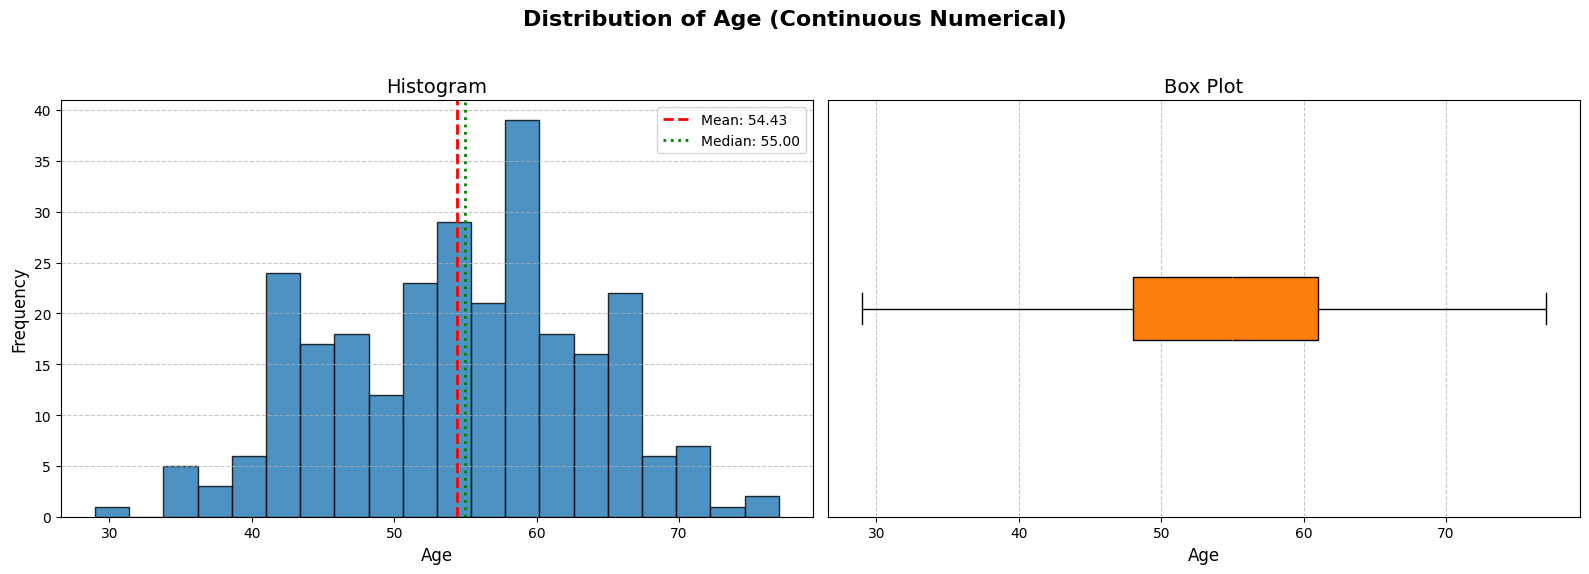

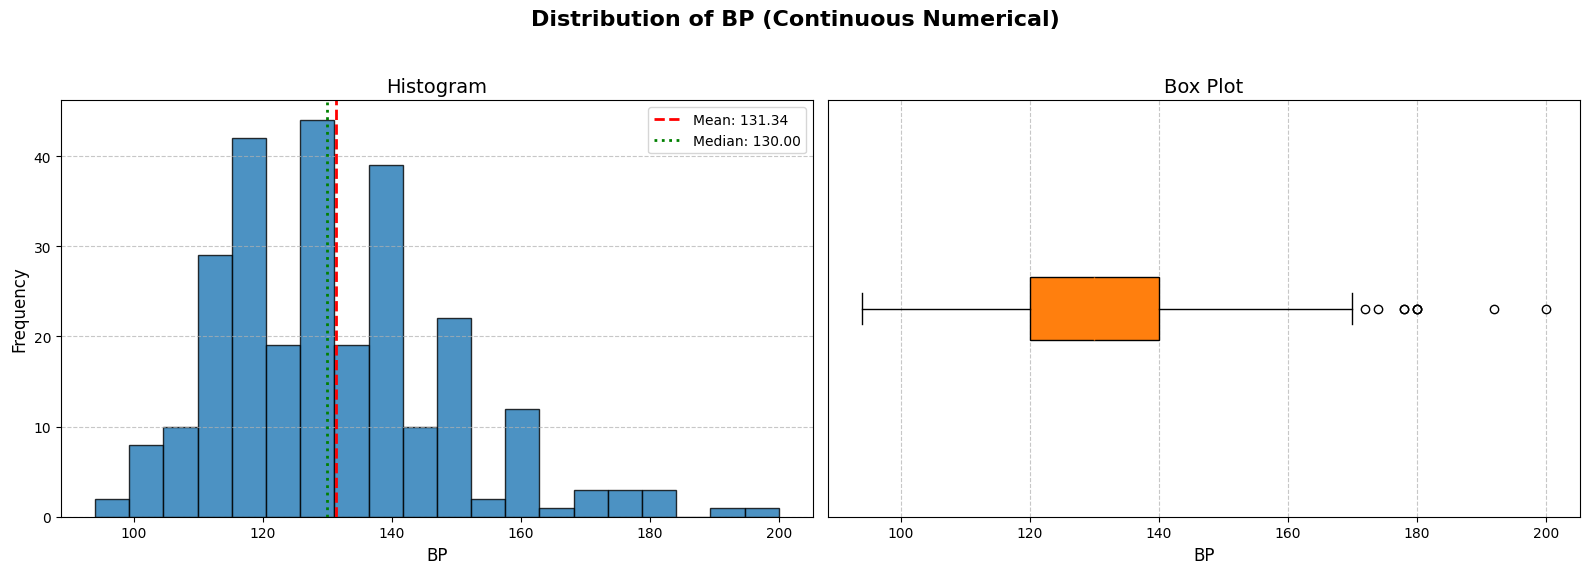

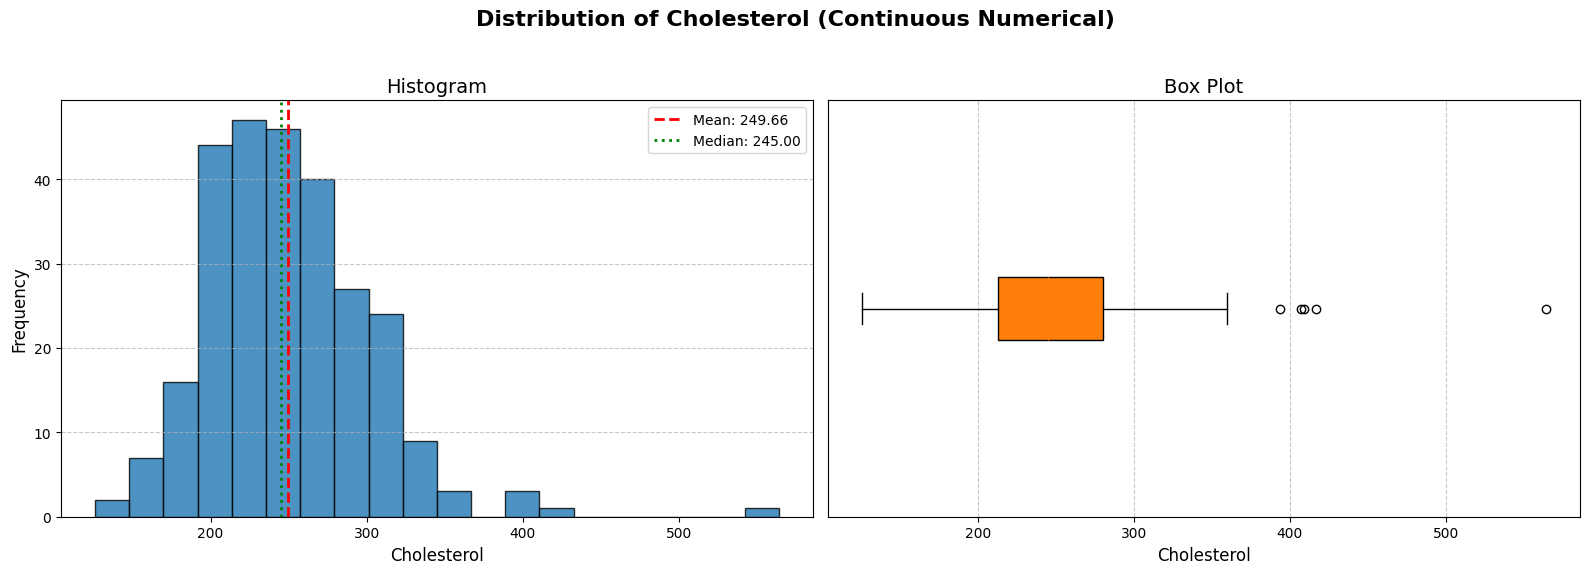

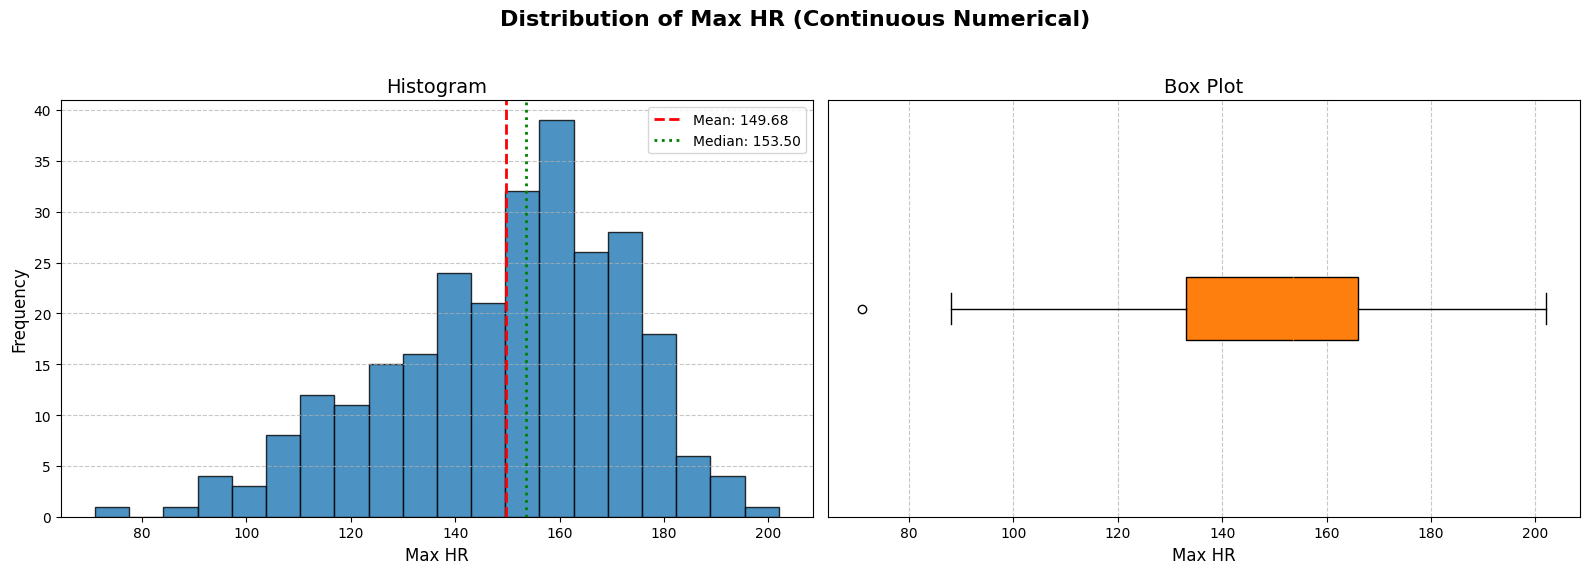

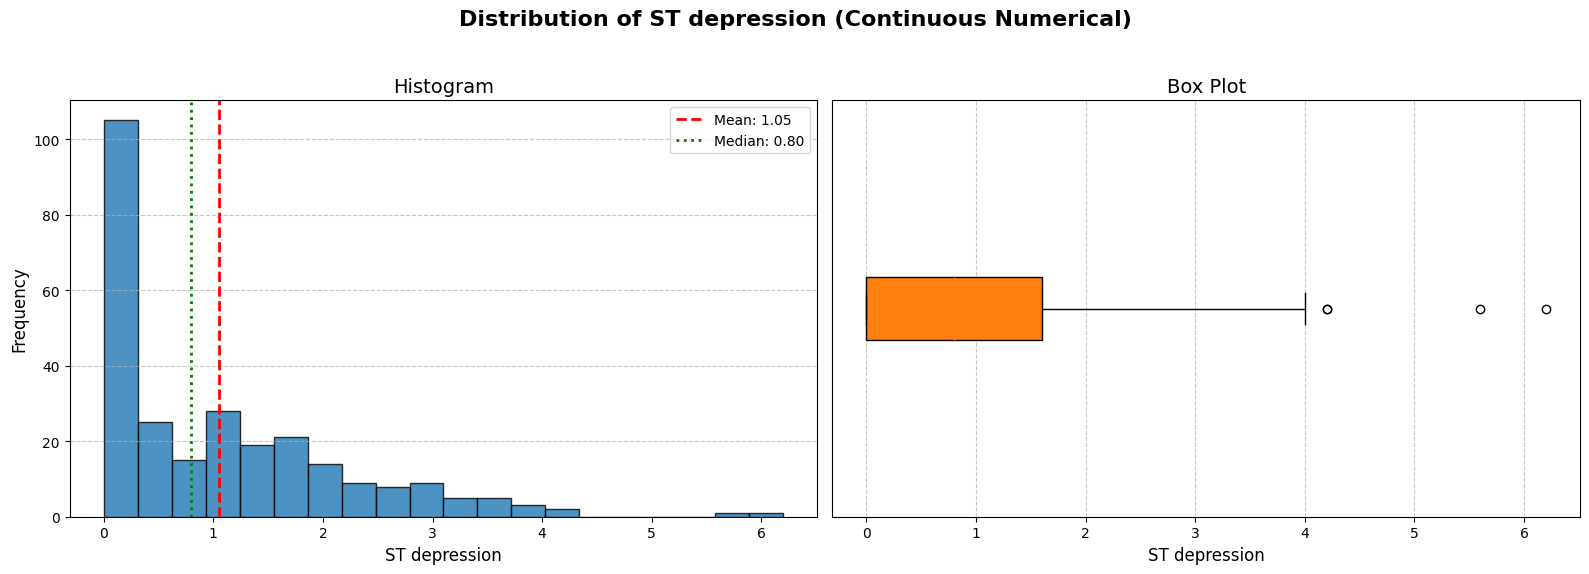


Generating plots for Discrete Numerical (Converted Categorical) Columns...


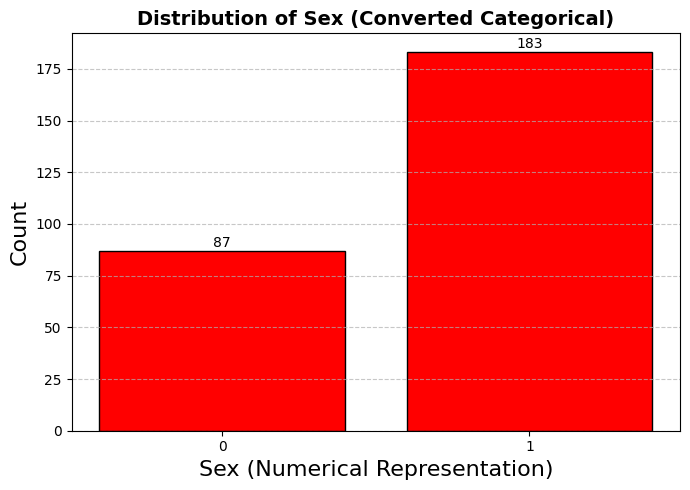

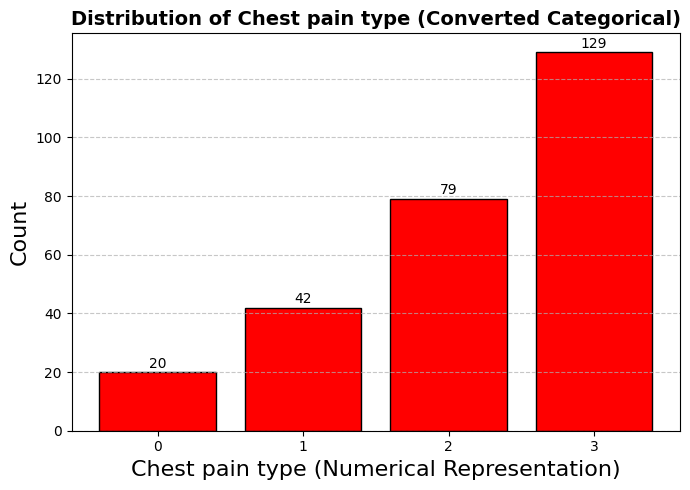

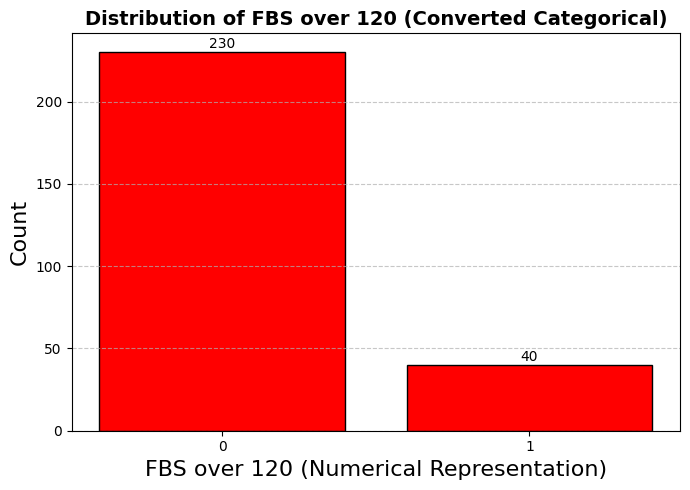

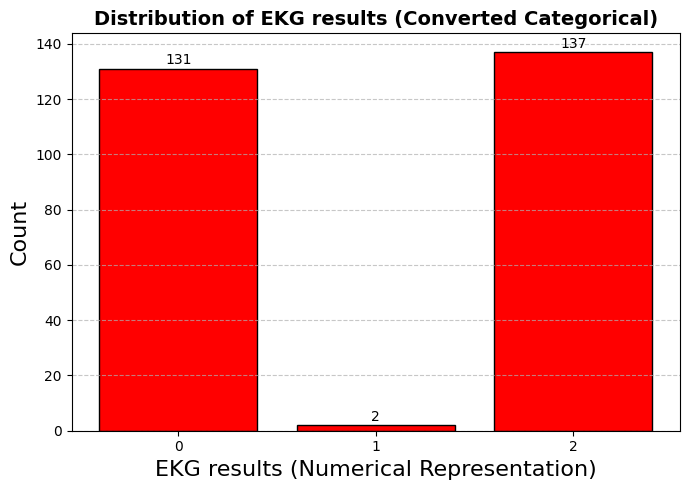

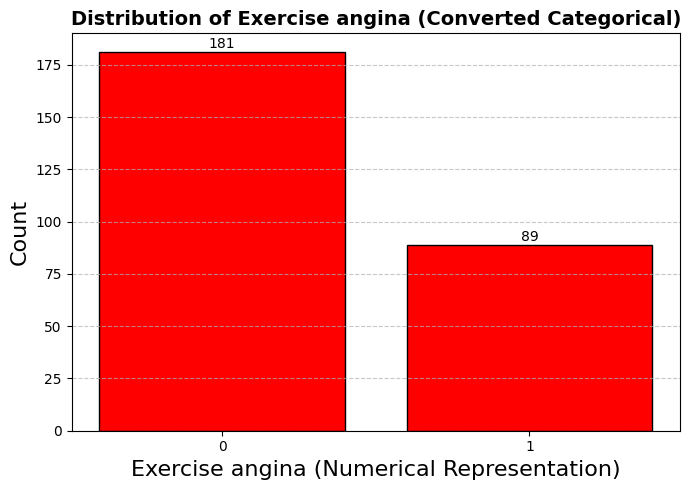

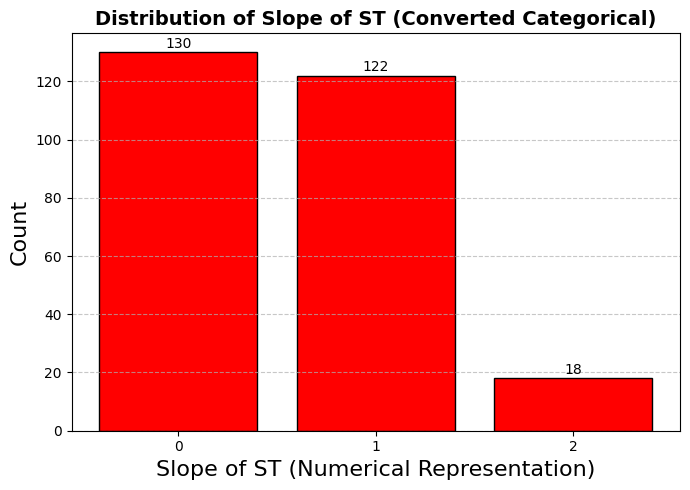

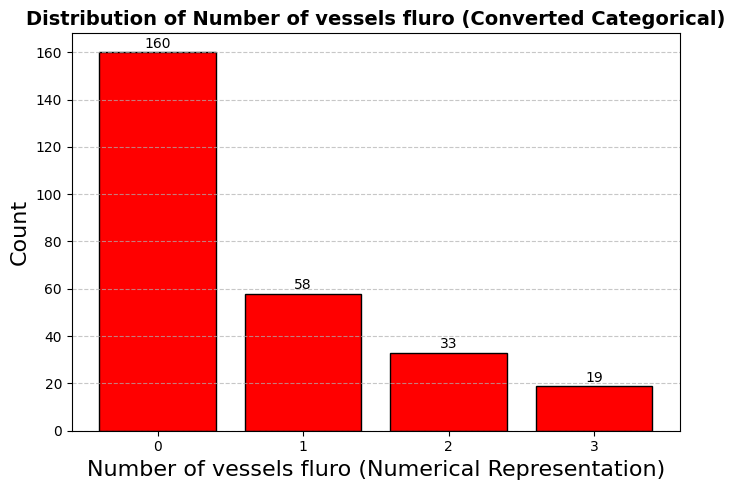

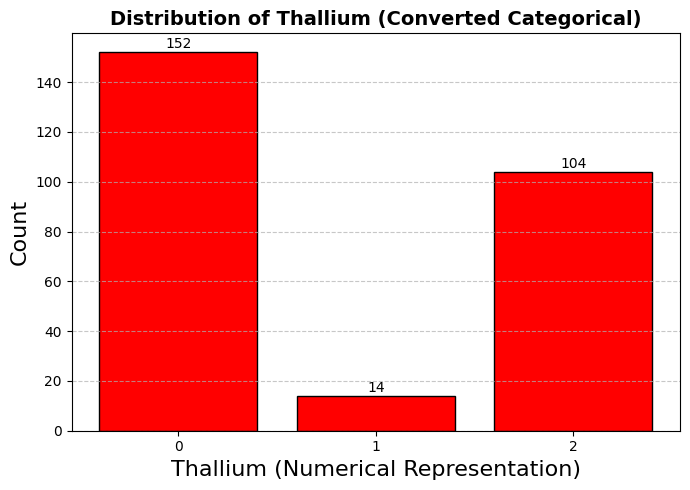

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Separate columns into continuous and discrete (converted categorical)
continuous_numerical_cols = []
discrete_numerical_cols = []

# Exclude 'Heart Disease' as it's the target and still categorical string in processed_data
excluded_cols = ['Heart Disease']

for idx, col_name in enumerate(headers):
    if col_name in excluded_cols:
        continue

    # Check if the column was originally categorical and converted to numerical
    if col_name in converted_categorical_cols_names:
        discrete_numerical_cols.append((col_name, idx))
    else:
        # Check if it's truly continuous numerical
        is_continuous = True
        temp_data = []
        for row in processed_data:
            if len(row) > idx:
                val = row[idx]
                if val == '': # Skip empty strings (potential missing values)
                    continue
                try:
                    temp_data.append(float(val))
                except ValueError:
                    is_continuous = False
                    break
        if is_continuous and temp_data: # Only add if it's truly numerical and has data
            continuous_numerical_cols.append((col_name, idx))

print("Continuous Numerical Columns:", [col[0] for col in continuous_numerical_cols])
print("Discrete Numerical (Converted Categorical) Columns:", [col[0] for col in discrete_numerical_cols])

# --- Plotting Continuous Numerical Columns ---
print("\nGenerating plots for Continuous Numerical Columns...")
for col_name, col_idx in continuous_numerical_cols:
    column_data = []
    for row in processed_data:
        if len(row) > col_idx:
            val = row[col_idx]
            if val == '': # Skip empty string values
                continue
            try:
                column_data.append(float(val))
            except ValueError:
                continue # Should not happen after initial checks

    if not column_data:
        print(f"Skipping visualization for continuous column '{col_name}' due to no valid data.")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Distribution of {col_name} (Continuous Numerical)', fontsize=16, weight='bold')

    # Histogram
    axes[0].hist(column_data, bins=20, edgecolor='black', color='#1f77b4', alpha=0.8)
    axes[0].set_title('Histogram', fontsize=14)
    axes[0].set_xlabel(col_name, fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    mean_val = np.mean(column_data)
    median_val = np.median(column_data)
    axes[0].axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axes[0].axvline(median_val, color='green', linestyle='dotted', linewidth=2, label=f'Median: {median_val:.2f}')
    axes[0].legend()

    # Box Plot
    axes[1].boxplot(column_data, vert=False, patch_artist=True, boxprops=dict(facecolor='#ff7f0e'))
    axes[1].set_title('Box Plot', fontsize=14)
    axes[1].set_xlabel(col_name, fontsize=12)
    axes[1].set_yticks([]) # Hide y-axis for horizontal box plot
    axes[1].grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout for suptitle
    plt.show()


# --- Plotting Discrete Numerical (Converted Categorical) Columns ---
print("\nGenerating plots for Discrete Numerical (Converted Categorical) Columns...")
for col_name, col_idx in discrete_numerical_cols:
    column_data = []
    for row in processed_data:
        if len(row) > col_idx:
            val = row[col_idx]
            if val == -1: # Skip -1 which represents missing values for converted categoricals
                continue
            try:
                column_data.append(int(val)) # Converted categoricals should be integers
            except ValueError:
                continue # Should not happen

    if not column_data:
        print(f"Skipping visualization for discrete column '{col_name}' due to no valid data.")
        continue

    unique_values, counts = np.unique(column_data, return_counts=True)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(unique_values, counts, color='red', edgecolor='black')
    ax.set_title(f'Distribution of {col_name} (Converted Categorical)', fontsize=14, weight='bold')
    ax.set_xlabel(f'{col_name} (Numerical Representation)', fontsize=16)
    ax.set_ylabel('Count', fontsize=16)
    ax.set_xticks(unique_values) # Ensure all unique values are shown on x-axis
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Add count annotations on top of bars
    for i, count in enumerate(counts):
        ax.text(unique_values[i], count + 0.5, str(count), ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


### Demonstrating Manual Categorical to Numerical Mapping for 'Sex'

The `convert_categorical_to_numerical` function in this notebook manually creates a numerical mapping for each unique category within the specified columns. Let's see this in action for the 'Sex' column.

In [13]:
# Get the index of the 'Sex' column
sex_col_idx = headers.index('Sex')

# Extract unique values from the original 'Sex' column (before conversion)
# We use raw_data to see the original categories
original_sex_values = [row[sex_col_idx] for row in raw_data if len(row) > sex_col_idx and row[sex_col_idx].strip() != '']
unique_original_sex = sorted(list(set(original_sex_values)))

# Manually create the mapping (as done internally by the function)
sex_mapping = {value: i for i, value in enumerate(unique_original_sex)}

print(f"Original unique values for 'Sex': {unique_original_sex}")
print(f"Manual numerical mapping for 'Sex': {sex_mapping}")

print("\nFirst 5 rows of 'Sex' column in processed_data (numerical representation):")
for i in range(min(5, len(processed_data))):
    if len(processed_data[i]) > sex_col_idx:
        print(f"Row {i}: Original value '{raw_data[i][sex_col_idx]}' -> Converted value '{processed_data[i][sex_col_idx]}' ")
    else:
        print(f"Row {i}: Data missing for 'Sex'")

Original unique values for 'Sex': ['0', '1']
Manual numerical mapping for 'Sex': {'0': 0, '1': 1}

First 5 rows of 'Sex' column in processed_data (numerical representation):
Row 0: Original value '1' -> Converted value '1' 
Row 1: Original value '0' -> Converted value '0' 
Row 2: Original value '1' -> Converted value '1' 
Row 3: Original value '1' -> Converted value '1' 
Row 4: Original value '0' -> Converted value '0' 


## Numerical Feature Normalization/Standardization

In [14]:
import math

# Helper function to calculate mean (re-defined for self-containment if not already in context)
def calculate_mean_manual(data_list):
    if not data_list:
        return None
    total = sum(data_list)
    return total / len(data_list)

# Helper function to calculate standard deviation (sample std dev)
def calculate_std_dev_manual(data_list):
    if len(data_list) < 2:
        return 0.0 if len(data_list) == 1 else None

    mean_val = calculate_mean_manual(data_list)
    if mean_val is None:
        return None

    sum_sq_diff = sum([(x - mean_val) ** 2 for x in data_list])
    return math.sqrt(sum_sq_diff / (len(data_list) - 1))

# Function to perform Z-score standardization manually
def z_score_standardize(data, headers, continuous_cols_info):
    standardized_data = [list(row) for row in data]

    for col_name, col_idx in continuous_cols_info:
        column_values = []
        for row in data:
            if len(row) > col_idx:
                try:
                    column_values.append(float(row[col_idx]))
                except ValueError:
                    continue # Skip non-numeric or missing values

        if column_values:
            mean_val = calculate_mean_manual(column_values)
            std_dev_val = calculate_std_dev_manual(column_values)

            if std_dev_val is not None and std_dev_val != 0:
                for r_idx, row in enumerate(standardized_data):
                    if len(row) > col_idx:
                        try:
                            val = float(row[col_idx])
                            standardized_data[r_idx][col_idx] = (val - mean_val) / std_dev_val
                        except ValueError:
                            # Keep non-numeric values as is or handle them specifically if needed
                            pass
    return standardized_data

print("Starting Z-score standardization for continuous numerical columns...")

# Perform standardization
standardized_processed_data = z_score_standardize(processed_data, headers, continuous_numerical_cols)

print("Z-score standardization complete.")

Starting Z-score standardization for continuous numerical columns...
Z-score standardization complete.


### Explanation of Z-score Standardization

**Method:** Z-score standardization (also known as standard scaling) transforms each feature such that it has a mean of 0 and a standard deviation of 1. The formula for standardization of a data point `x` is:

`z = (x - μ) / σ`

Where:
*   `μ` (mu) is the mean of the feature.
*   `σ` (sigma) is the standard deviation of the feature.

**When to use:**
*   **Machine Learning Algorithms:** Many machine learning algorithms (e.g., K-Means, SVM, PCA, Neural Networks, Linear Regression, Logistic Regression) perform better or converge faster when features are on a similar scale. Algorithms that calculate distances between data points are particularly sensitive to feature scales.
*   **Normally Distributed Data:** It is particularly effective when the data follows a Gaussian (normal) distribution, as it retains information about the distribution's shape while centering and scaling it.
*   **Outlier Handling:** While not making data immune to outliers, standardization scales outliers proportionally, rather than compressing them like min-max normalization might. This can help algorithms treat them more consistently relative to the rest of the data. However, for extremely skewed data, robust scalers (using median and IQR) might be preferred.

**Pros:**
*   **Prevents feature dominance:** Features with larger numerical ranges do not disproportionately influence model training.
*   **Faster convergence:** Helps gradient-descent-based algorithms converge more quickly.
*   **Handles outliers proportionally:** Does not squash the effects of outliers, maintaining their relative distance.

**Cons:**
*   **Impacted by outliers:** The mean and standard deviation are sensitive to outliers, so extreme values can distort the scaled data. If outliers are a major concern, robust scaling might be more appropriate.
*   **Loss of interpretability:** The original scale and units of the features are lost, making the standardized values less directly interpretable.

In [15]:
import numpy as np

print("--- Comparing original and standardized values for a few continuous columns ---")

# Select a few columns to demonstrate (e.g., 'Age', 'BP', 'Cholesterol')
demo_cols = ['Age', 'BP', 'Cholesterol']

for col_name in demo_cols:
    col_idx = headers.index(col_name)

    original_values = []
    standardized_values = []

    for i in range(len(processed_data)):
        if len(processed_data[i]) > col_idx:
            try:
                original_values.append(float(processed_data[i][col_idx]))
                standardized_values.append(standardized_processed_data[i][col_idx])
            except ValueError:
                continue

    if original_values:
        print(f"\nColumn: '{col_name}'")
        print(f"  Original Data - Mean: {calculate_mean_manual(original_values):.2f}, Std Dev: {calculate_std_dev_manual(original_values):.2f}")
        print(f"  Standardized Data - Mean: {calculate_mean_manual(standardized_values):.2f}, Std Dev: {calculate_std_dev_manual(standardized_values):.2f}")

        # Display first 5 original and standardized values
        print(f"  First 5 values (Original vs. Standardized):")
        for i in range(min(5, len(original_values))):
            print(f"    {original_values[i]:.2f} -> {standardized_values[i]:.4f}")
    else:
        print(f"\nNo valid numerical data found for column '{col_name}' to demonstrate standardization.")

--- Comparing original and standardized values for a few continuous columns ---

Column: 'Age'
  Original Data - Mean: 54.43, Std Dev: 9.11
  Standardized Data - Mean: 0.00, Std Dev: 1.00
  First 5 values (Original vs. Standardized):
    70.00 -> 1.7089
    67.00 -> 1.3796
    57.00 -> 0.2818
    64.00 -> 1.0502
    74.00 -> 2.1480

Column: 'BP'
  Original Data - Mean: 131.34, Std Dev: 17.86
  Standardized Data - Mean: 0.00, Std Dev: 1.00
  First 5 values (Original vs. Standardized):
    130.00 -> -0.0753
    115.00 -> -0.9151
    124.00 -> -0.4112
    128.00 -> -0.1872
    120.00 -> -0.6351

Column: 'Cholesterol'
  Original Data - Mean: 249.66, Std Dev: 51.69
  Standardized Data - Mean: -0.00, Std Dev: 1.00
  First 5 values (Original vs. Standardized):
    322.00 -> 1.3996
    564.00 -> 6.0817
    261.00 -> 0.2194
    263.00 -> 0.2581
    269.00 -> 0.3742


one hot encoding

In [16]:
import numpy as np

# Function to fit the One-Hot Encoder (learn unique categories)
def fit_one_hot_encoder(data, headers, categorical_cols_info):
    """
    Learns unique categories for specified categorical columns.

    Args:
        data: The dataset (list of lists).
        headers: The list of column headers.
        categorical_cols_info: A list of (column_name, column_index) tuples
                               for columns to be one-hot encoded.

    Returns:
        A dictionary where keys are column names and values are sorted lists of
        unique categories found in that column.
    """
    category_maps = {}
    for col_name, col_idx in categorical_cols_info:
        unique_categories = set()
        for row in data:
            if len(row) > col_idx:
                val = row[col_idx]
                if val != -1: # Exclude our missing value placeholder
                    unique_categories.add(val)
        category_maps[col_name] = sorted(list(unique_categories))
    return category_maps

# Function to transform data using the fitted One-Hot Encoder
def transform_one_hot_encoder(data, headers, category_maps, categorical_cols_info):
    """
    Applies one-hot encoding to specified categorical columns based on learned categories.

    Args:
        data: The dataset (list of lists) to be transformed.
        headers: The current list of column headers.
        category_maps: A dictionary of learned unique categories from fit_one_hot_encoder.
        categorical_cols_info: A list of (column_name, column_index) tuples
                               for columns to be one-hot encoded.

    Returns:
        A tuple containing:
        - new_headers: The updated list of headers with one-hot encoded columns.
        - encoded_data: The dataset with specified columns one-hot encoded.
    """
    new_headers = []
    encoded_data_rows = []

    # Create a mapping from column name to its original index for easy lookup
    col_name_to_idx = {name: idx for idx, name in enumerate(headers)}
    categorical_col_names_to_encode = {col_info[0] for col_info in categorical_cols_info} # Set for quick lookup

    # First pass: build new headers
    for col_name in headers:
        if col_name in categorical_col_names_to_encode:
            categories = category_maps.get(col_name, [])
            for cat in categories:
                new_headers.append(f"{col_name}_{cat}")
        else:
            new_headers.append(col_name)

    # Second pass: fill encoded data row by row
    for r_idx, row in enumerate(data):
        new_row = []
        for col_name in headers:
            if col_name in categorical_col_names_to_encode:
                categories = category_maps.get(col_name, [])
                original_value = None
                if len(row) > col_name_to_idx[col_name]:
                    original_value = row[col_name_to_idx[col_name]]

                # Create one-hot vector
                one_hot_vector = [0] * len(categories)
                if original_value in categories:
                    try:
                        cat_index = categories.index(original_value)
                        one_hot_vector[cat_index] = 1
                    except ValueError:
                        # Should not happen if original_value in categories check passes
                        pass
                new_row.extend(one_hot_vector)
            else:
                # For non-categorical columns, just append the original value
                if len(row) > col_name_to_idx[col_name]:
                    new_row.append(row[col_name_to_idx[col_name]])
                else:
                    new_row.append(None) # Or appropriate placeholder for missing non-categorical data
        encoded_data_rows.append(new_row)

    return new_headers, encoded_data_rows

print("--- Performing One-Hot Encoding ---")

# Separate columns into continuous and discrete (converted categorical)
continuous_numerical_cols = []
discrete_numerical_cols = []

# Exclude 'Heart Disease' as it's the target and still categorical string in processed_data
excluded_cols = ['Heart Disease']

for idx, col_name in enumerate(headers):
    if col_name in excluded_cols:
        continue

    # Check if the column was originally categorical and converted to numerical
    if col_name in converted_categorical_cols_names:
        discrete_numerical_cols.append((col_name, idx))
    else:
        # Check if it's truly continuous numerical
        is_continuous = True
        temp_data = []
        for row in processed_data:
            if len(row) > idx:
                val = row[idx]
                if val == '': # Skip empty strings (potential missing values)
                    continue
                try:
                    temp_data.append(float(val))
                except ValueError:
                    is_continuous = False
                    break
        if is_continuous and temp_data: # Only add if it's truly numerical and has data
            continuous_numerical_cols.append((col_name, idx))

# 'Fit' the one-hot encoder on the current processed_data to learn categories
one_hot_category_maps = fit_one_hot_encoder(processed_data, headers, discrete_numerical_cols)
print("Learned Categories for One-Hot Encoding:", one_hot_category_maps)

# 'Transform' the processed_data using the learned categories
one_hot_encoded_headers, one_hot_encoded_data = transform_one_hot_encoder(processed_data, headers, one_hot_category_maps, discrete_numerical_cols)

print("\nOne-Hot Encoding complete.")
print(f"Original number of columns: {len(headers)}")
print(f"New number of columns after One-Hot Encoding: {len(one_hot_encoded_headers)}")

print("\nFirst 5 rows of One-Hot Encoded Data (with new headers):")
# Display headers
print(one_hot_encoded_headers)
# Display first 5 rows
for i in range(min(5, len(one_hot_encoded_data))):
    print(one_hot_encoded_data[i])

--- Performing One-Hot Encoding ---
Learned Categories for One-Hot Encoding: {'Sex': [0, 1], 'Chest pain type': [0, 1, 2, 3], 'FBS over 120': [0, 1], 'EKG results': [0, 1, 2], 'Exercise angina': [0, 1], 'Slope of ST': [0, 1, 2], 'Number of vessels fluro': [0, 1, 2, 3], 'Thallium': [0, 1, 2]}

One-Hot Encoding complete.
Original number of columns: 14
New number of columns after One-Hot Encoding: 29

First 5 rows of One-Hot Encoded Data (with new headers):
['Age', 'Sex_0', 'Sex_1', 'Chest pain type_0', 'Chest pain type_1', 'Chest pain type_2', 'Chest pain type_3', 'BP', 'Cholesterol', 'FBS over 120_0', 'FBS over 120_1', 'EKG results_0', 'EKG results_1', 'EKG results_2', 'Max HR', 'Exercise angina_0', 'Exercise angina_1', 'ST depression', 'Slope of ST_0', 'Slope of ST_1', 'Slope of ST_2', 'Number of vessels fluro_0', 'Number of vessels fluro_1', 'Number of vessels fluro_2', 'Number of vessels fluro_3', 'Thallium_0', 'Thallium_1', 'Thallium_2', 'Heart Disease']
['70', 0, 1, 0, 0, 0, 1, '13

 summary of the output:

Learned Categories for One-Hot Encoding: The model identified the unique categories for each specified categorical column (e.g., 'Sex': 0, 1; 'Chest pain type': 0, 1, 2, 3, etc.). This mapping is crucial for the encoding process.
The process transformed the original 14 columns into 29 columns. This increase is expected as each categorical feature with 'N' categories is expanded into 'N' new binary columns.
First 5 rows of One-Hot Encoded Data: You can see the new headers, which now include binary columns for each category (e.g., 'Sex_0', 'Sex_1'). The corresponding data rows show 0 or 1 for these new columns, indicating the presence or absence of a particular category for that record.


## Feature Engineering: Creating a 'Risk Factor'

We will now create a new, more complex feature called `risk_factor` by combining 'Cholesterol' and 'Max HR' (Thalach). This feature will involve:

1.  **Base Risk Components**: Scaling 'Cholesterol' and 'Max HR' values.
2.  **Interaction Term**: Multiplying the scaled cholesterol and Max HR to capture their combined effect.
3.  **Complex Formula**: Using a non-linear combination of these terms.
4.  **Percentile-based Ranking**: Converting the calculated `risk_factor` into percentile ranks to normalize its distribution and make it more interpretable in terms of relative risk within the dataset.

In [17]:
import numpy as np
from scipy.stats import rankdata

print("--- Creating 'risk_factor' feature ---")

# Get indices for 'Cholesterol' and 'Max HR' from the one_hot_encoded_headers
chol_col_idx = one_hot_encoded_headers.index('Cholesterol')
max_hr_col_idx = one_hot_encoded_headers.index('Max HR')

cholesterol_values = []
max_hr_values = []

# Extract numerical values for calculation
for row in one_hot_encoded_data:
    try:
        cholesterol_values.append(float(row[chol_col_idx]))
        max_hr_values.append(float(row[max_hr_col_idx]))
    except (ValueError, IndexError):
        # Handle cases where data might be missing or non-numeric (though ideally pre-cleaned)
        cholesterol_values.append(np.nan) # Use NaN for missing values
        max_hr_values.append(np.nan)

# Convert to numpy arrays for easier computation, handling NaNs
cholesterol_values = np.array(cholesterol_values)
max_hr_values = np.array(max_hr_values)

# Define thresholds/scaling factors based on hypothetical domain knowledge
# (These are illustrative; real domain knowledge would come from experts)
HEALTHY_CHOL_THRESHOLD = 200.0 # mg/dL
AVG_MAX_HR = 150.0 # bpm (typical average max HR estimation)

# Calculate base risk components, handling potential division by zero for Max HR
cholesterol_scaled = cholesterol_values / HEALTHY_CHOL_THRESHOLD
max_hr_scaled = np.where(max_hr_values != 0, max_hr_values / AVG_MAX_HR, 0) # Avoid division by zero

# Complex formula with interaction term
# For demonstration, let's use: (cholesterol_scaled)^2 + max_hr_scaled + (cholesterol_scaled * max_hr_scaled)
initial_risk_factor = (cholesterol_scaled ** 2) + max_hr_scaled + (cholesterol_scaled * max_hr_scaled)

# Handle NaNs that might have resulted from initial data extraction or calculations
# For simplicity, we'll impute NaNs in initial_risk_factor with the median before ranking
median_risk = np.nanmedian(initial_risk_factor)
initial_risk_factor_imputed = np.nan_to_num(initial_risk_factor, nan=median_risk)

# Percentile-based ranking
# rankdata returns ranks, convert to percentiles (0-100)
risk_factor_percentiles = (rankdata(initial_risk_factor_imputed, method='average') / len(initial_risk_factor_imputed)) * 100

# Add the new feature to the one_hot_encoded_data and headers
new_feature_name = 'risk_factor'
one_hot_encoded_headers.append(new_feature_name)

for i, row in enumerate(one_hot_encoded_data):
    row.append(risk_factor_percentiles[i])

print(f"New feature '{new_feature_name}' created and added to the dataset.")
print(f"Updated number of columns: {len(one_hot_encoded_headers)}")

print("\nFirst 5 rows with new 'risk_factor' feature:")
print(one_hot_encoded_headers)
for i in range(min(5, len(one_hot_encoded_data))):
    print(one_hot_encoded_data[i])

--- Creating 'risk_factor' feature ---
New feature 'risk_factor' created and added to the dataset.
Updated number of columns: 30

First 5 rows with new 'risk_factor' feature:
['Age', 'Sex_0', 'Sex_1', 'Chest pain type_0', 'Chest pain type_1', 'Chest pain type_2', 'Chest pain type_3', 'BP', 'Cholesterol', 'FBS over 120_0', 'FBS over 120_1', 'EKG results_0', 'EKG results_1', 'EKG results_2', 'Max HR', 'Exercise angina_0', 'Exercise angina_1', 'ST depression', 'Slope of ST_0', 'Slope of ST_1', 'Slope of ST_2', 'Number of vessels fluro_0', 'Number of vessels fluro_1', 'Number of vessels fluro_2', 'Number of vessels fluro_3', 'Thallium_0', 'Thallium_1', 'Thallium_2', 'Heart Disease', 'risk_factor']
['70', 0, 1, 0, 0, 0, 1, '130', '322', 1, 0, 0, 0, 1, '109', 1, 0, '2.4', 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 'Presence', np.float64(78.51851851851852)]
['67', 1, 0, 0, 0, 1, 0, '115', '564', 1, 0, 0, 0, 1, '160', 1, 0, '1.6', 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 'Absence', np.float64(100.0)]
['57', 0, 1, 0, 

In [21]:
print("--- Storing Processed Data to CSV ---")

OUTPUT_FILE_PATH = "processed_heart_disease_data.csv"

# Ensure all data points are strings for CSV writing
def format_value_for_csv(value):
    if isinstance(value, (int, float, np.integer, np.floating)):
        # Format floats to 4 decimal places for consistency if not integer
        if isinstance(value, float) and not value.is_integer():
            return f"{value:.4f}"
        return str(int(value))
    elif value is None or value == '':
        return '' # Represent None or empty as empty string in CSV
    return str(value)

with open(OUTPUT_FILE_PATH, 'w', newline='', encoding='utf-8') as outfile:
    # Write headers
    outfile.write(','.join([format_value_for_csv(h) for h in one_hot_encoded_headers]) + '\n')

    # Write data rows
    for row in one_hot_encoded_data:
        outfile.write(','.join([format_value_for_csv(val) for val in row]) + '\n')

print(f"Processed data successfully written to '{OUTPUT_FILE_PATH}'.")

--- Storing Processed Data to CSV ---
Processed data successfully written to 'processed_heart_disease_data.csv'.


Create histograms for all numerical features without using built-in plotting functions, implementing binning and frequency calculations manually.

In [25]:
import math

def generate_manual_histogram(column_name, column_data, is_continuous=True, num_bins=10):
    """
    Generates a text-based histogram for a given numerical column.
    Manually implements binning and frequency counting.
    """
    print(f"\n--- Manual Histogram for '{column_name}' ---")

    # Filter out invalid (non-numeric, empty, or missing placeholder) values
    numeric_data = []
    for item in column_data:
        try:
            # Handle string representation of numbers and actual numbers
            val = float(item)
            if not math.isnan(val) and val != -1: # Exclude NaN and our -1 placeholder
                numeric_data.append(val)
        except (ValueError, TypeError):
            continue

    if not numeric_data:
        print(f"No valid numerical data to plot for '{column_name}'.")
        return

    if is_continuous:
        min_val = min(numeric_data)
        max_val = max(numeric_data)

        if min_val == max_val:
            print(f"All values in '{column_name}' are the same: {min_val}")
            print(f"{min_val}: {'#' * len(numeric_data)}")
            return

        bin_width = (max_val - min_val) / num_bins
        bins = [min_val + i * bin_width for i in range(num_bins + 1)]
        counts = [0] * num_bins

        for value in numeric_data:
            if value == max_val: # Handle edge case for max_val to be included in the last bin
                counts[num_bins - 1] += 1
            else:
                for i in range(num_bins):
                    if bins[i] <= value < bins[i+1]:
                        counts[i] += 1
                        break

        max_count = max(counts)
        if max_count == 0:
            print("No data points fall into any bin.")
            return

        # Text-based visualization
        scale = 50.0 / max_count # Scale to fit within 50 characters
        for i in range(num_bins):
            bin_start = f"{bins[i]:.2f}"
            bin_end = f"{bins[i+1]:.2f}"
            bar = '#' * int(counts[i] * scale)
            print(f"[{bin_start} - {bin_end}): {bar} ({counts[i]} entries)")

    else: # Discrete (converted categorical)
        value_counts = {}
        for value in numeric_data:
            value_counts[int(value)] = value_counts.get(int(value), 0) + 1

        if not value_counts:
            print("No data points to count for discrete column.")
            return

        sorted_values = sorted(value_counts.keys())
        max_count = max(value_counts.values())

        # Text-based visualization
        scale = 50.0 / max_count # Scale to fit within 50 characters
        for value in sorted_values:
            count = value_counts[value]
            bar = '#' * int(count * scale)
            print(f"{value}: {bar} ({count} entries)")

# --- Identify numerical columns again, ensuring `processed_data` is up-to-date ---
# The `processed_data` and `headers` are from the 'One-Hot Encoding' cell which is the latest state.

# NOTE: processed_data at this point is `one_hot_encoded_data` as per the previous cell.
# The headers are `one_hot_encoded_headers`.
current_headers = one_hot_encoded_headers
current_data = one_hot_encoded_data

# Re-evaluate which columns are truly numerical for histogram plotting
continuous_numerical_cols_for_hist = []
discrete_numerical_cols_for_hist = []

# Columns that might be numerical but are intended as identifiers or target
# and should be excluded from general numerical analysis (if applicable)
# 'Heart Disease' is the target. 'Sex_0', 'Sex_1' etc. are one-hot encoded, not discrete originals.
excluded_from_hist = ['Heart Disease'] + \
                     [h for h in current_headers if h.startswith(('Sex_', 'Chest pain type_', 'FBS over 120_', 'EKG results_', 'Exercise angina_', 'Slope of ST_', 'Number of vessels fluro_', 'Thallium_'))]

for idx, col_name in enumerate(current_headers):
    if col_name in excluded_from_hist:
        continue

    # Check if column values are consistently numerical
    sample_values = []
    for row in current_data:
        if len(row) > idx:
            sample_values.append(row[idx])

    is_numeric = True
    contains_float = False
    if not sample_values:
        is_numeric = False
    else:
        for val in sample_values:
            try:
                f_val = float(val)
                if f_val != int(f_val): # Check if it's a true float (not an integer represented as float)
                    contains_float = True
            except (ValueError, TypeError):
                is_numeric = False
                break

    if is_numeric:
        if contains_float: # Likely continuous
            continuous_numerical_cols_for_hist.append((col_name, idx))
        else: # Likely discrete (integer-like numbers)
            discrete_numerical_cols_for_hist.append((col_name, idx))

print("Continuous Numerical Columns for Histograms:", [col[0] for col in continuous_numerical_cols_for_hist])
print("Discrete Numerical (Integer-like) Columns for Histograms:", [col[0] for col in discrete_numerical_cols_for_hist])

# --- Generate Histograms for Continuous Numerical Columns ---
for col_name, col_idx in continuous_numerical_cols_for_hist:
    column_data = [row[col_idx] for row in current_data if len(row) > col_idx]
    generate_manual_histogram(col_name, column_data, is_continuous=True, num_bins=15) # Increased bins for more detail

# --- Generate Histograms for Discrete Numerical Columns ---
for col_name, col_idx in discrete_numerical_cols_for_hist:
    column_data = [row[col_idx] for row in current_data if len(row) > col_idx]
    generate_manual_histogram(col_name, column_data, is_continuous=False)


Continuous Numerical Columns for Histograms: ['ST depression', 'risk_factor']
Discrete Numerical (Integer-like) Columns for Histograms: ['Age', 'BP', 'Cholesterol', 'Max HR']

--- Manual Histogram for 'ST depression' ---
[0.00 - 0.41): ################################################## (113 entries)
[0.41 - 0.83): ############ (29 entries)
[0.83 - 1.24): ############# (31 entries)
[1.24 - 1.65): ############# (30 entries)
[1.65 - 2.07): ########## (23 entries)
[2.07 - 2.48): #### (10 entries)
[2.48 - 2.89): ##### (12 entries)
[2.89 - 3.31): ### (8 entries)
[3.31 - 3.72): ### (7 entries)
[3.72 - 4.13): # (3 entries)
[4.13 - 4.55):  (2 entries)
[4.55 - 4.96):  (0 entries)
[4.96 - 5.37):  (0 entries)
[5.37 - 5.79):  (1 entries)
[5.79 - 6.20):  (1 entries)

--- Manual Histogram for 'risk_factor' ---
[0.37 - 7.01): ################################################## (18 entries)
[7.01 - 13.65): ################################################## (18 entries)
[13.65 - 20.30): #################

Generating manual box plots for continuous numerical columns...

--- Box Plot Statistics for 'ST depression' ---
Q1 (25th percentile): 0.00
Median (Q2/50th percentile): 0.80
Q3 (75th percentile): 1.65
IQR (Interquartile Range): 1.65
Lower Fence: -2.48
Upper Fence: 4.12
Lower Whisker: 0.00
Upper Whisker: 4.00
Number of Outliers detected: 4
Sample Outliers: [4.2, 4.2, 5.6, 6.2]...


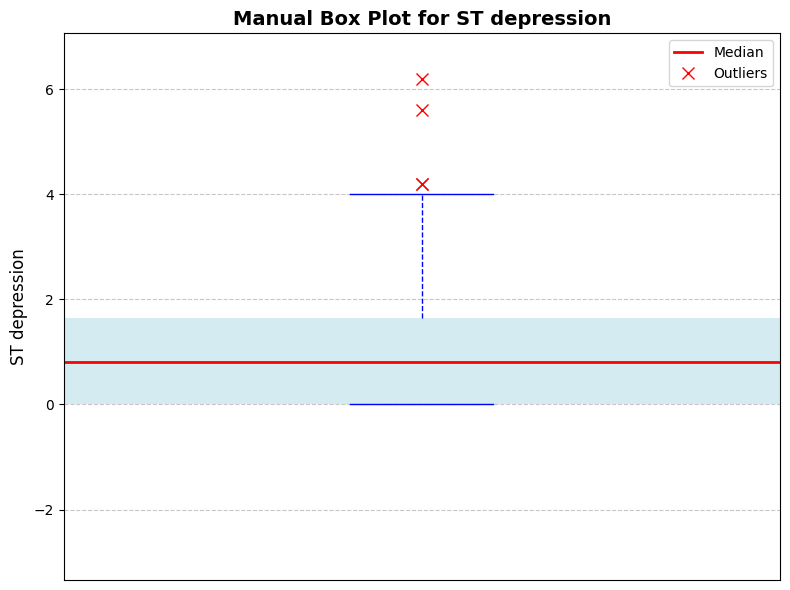


--- Box Plot Statistics for 'risk_factor' ---
Q1 (25th percentile): 25.09
Median (Q2/50th percentile): 50.19
Q3 (75th percentile): 75.28
IQR (Interquartile Range): 50.19
Lower Fence: -50.19
Upper Fence: 150.56
Lower Whisker: 0.37
Upper Whisker: 100.00
Number of Outliers detected: 0


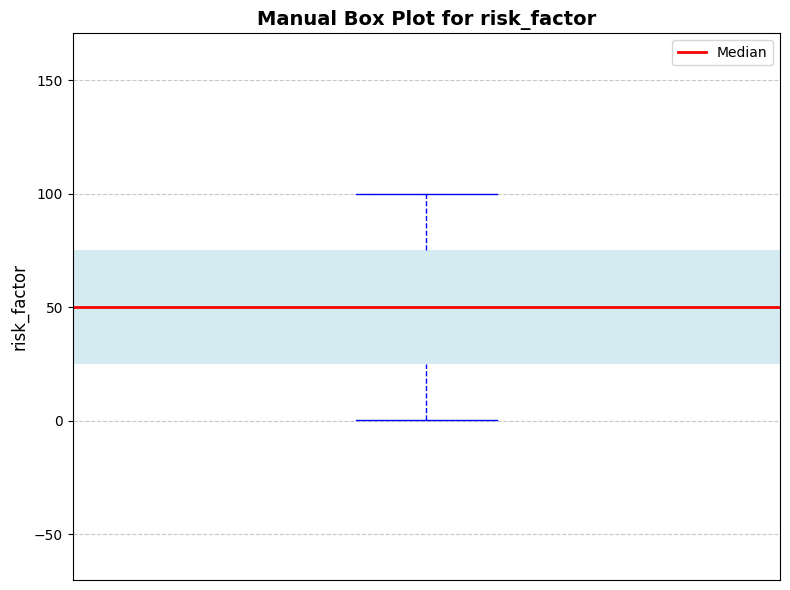

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import math

# Helper functions to calculate quartiles, IQR, and fences
def calculate_quartiles_iqr_fences(data_list):
    numeric_data = []
    for x in data_list:
        try:
            numeric_data.append(float(x))
        except ValueError:
            continue
    if not numeric_data:
        return None, None, None, None, None, None, None, None, None

    sorted_data = sorted(numeric_data)
    n = len(sorted_data)

    # Linear interpolation for quartiles (common method)
    def interpolate_quartile(sorted_arr, index):
        if index < 0:
            return sorted_arr[0]
        if index >= len(sorted_arr) - 1:
            return sorted_arr[-1]

        lower_idx = int(math.floor(index))
        upper_idx = int(math.ceil(index))

        if lower_idx == upper_idx:
            return sorted_arr[lower_idx]

        fraction = index - lower_idx
        return sorted_arr[lower_idx] * (1 - fraction) + sorted_arr[upper_idx] * fraction

    # Using (n+1) * p / 100 - 1 as index for quartile calculation
    q1 = interpolate_quartile(sorted_data, (n + 1) / 4 - 1)
    q2 = interpolate_quartile(sorted_data, (n + 1) / 2 - 1)
    q3 = interpolate_quartile(sorted_data, 3 * (n + 1) / 4 - 1)

    iqr = q3 - q1

    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    # Determine whiskers: farthest non-outlier data point within 1.5 * IQR
    lower_whisker = min(val for val in sorted_data if val >= lower_fence)
    upper_whisker = max(val for val in sorted_data if val <= upper_fence)

    return q1, q2, q3, iqr, lower_fence, upper_fence, lower_whisker, upper_whisker, sorted_data

# Use current_headers and current_data from the environment
# continuous_numerical_cols_for_hist was defined in a previous cell

print("Generating manual box plots for continuous numerical columns...")

for col_name, col_idx in continuous_numerical_cols_for_hist:
    column_data_raw = [row[col_idx] for row in current_data if len(row) > col_idx]

    q1, q2, q3, iqr, lower_fence, upper_fence, lower_whisker, upper_whisker, sorted_column_data = calculate_quartiles_iqr_fences(column_data_raw)

    if q1 is None:
        print(f"Skipping box plot for '{col_name}' due to no valid numerical data.")
        continue

    print(f"\n--- Box Plot Statistics for '{col_name}' ---")
    print(f"Q1 (25th percentile): {q1:.2f}")
    print(f"Median (Q2/50th percentile): {q2:.2f}")
    print(f"Q3 (75th percentile): {q3:.2f}")
    print(f"IQR (Interquartile Range): {iqr:.2f}")
    print(f"Lower Fence: {lower_fence:.2f}")
    print(f"Upper Fence: {upper_fence:.2f}")
    print(f"Lower Whisker: {lower_whisker:.2f}")
    print(f"Upper Whisker: {upper_whisker:.2f}")

    outliers = [val for val in sorted_column_data if val < lower_fence or val > upper_fence]
    print(f"Number of Outliers detected: {len(outliers)}")
    if outliers:
        print(f"Sample Outliers: {sorted(outliers)[:5]}...") # Show first 5 outliers

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(f'Manual Box Plot for {col_name}', fontsize=14, weight='bold')
    ax.set_ylabel(col_name, fontsize=12)
    ax.set_xticks([]) # Hide x-axis ticks for a single box plot

    # Drawing the box (Q1 to Q3)
    ax.axhspan(q1, q3, facecolor='lightblue', alpha=0.5)

    # Drawing the median line (Q2)
    ax.axhline(q2, color='red', linestyle='-', linewidth=2, label='Median')

    # Drawing the whiskers
    # Lower whisker
    ax.vlines(1, lower_whisker, q1, color='blue', linestyle='--', linewidth=1)
    ax.axhline(lower_whisker, color='blue', linestyle='-', linewidth=1, xmin=0.4, xmax=0.6) # cap
    # Upper whisker
    ax.vlines(1, q3, upper_whisker, color='blue', linestyle='--', linewidth=1)
    ax.axhline(upper_whisker, color='blue', linestyle='-', linewidth=1, xmin=0.4, xmax=0.6) # cap

    # Drawing outliers
    if outliers:
        ax.plot([1] * len(outliers), outliers, 'rx', markersize=8, label='Outliers')

    # Set x-axis limits to center the box plot
    ax.set_xlim(0.5, 1.5)
    # Set y-axis limits to fit all data points including outliers, with some padding
    min_val_plot = min(sorted_column_data[0], lower_fence)
    max_val_plot = max(sorted_column_data[-1], upper_fence)
    padding = (max_val_plot - min_val_plot) * 0.1 # 10% padding
    ax.set_ylim(min_val_plot - padding, max_val_plot + padding)

    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()